# EDA sobre embeddings AlphaEarth Foundations v2.1 (64 dimensiones)

Este notebook evalúa si los embeddings AlphaEarth de Google (64 números por
píxel y por año) sirven para distinguir tipos de cultivos en dos países:

1. **Italia** — 3 regiones piloto (Pianura Padana, Toscana centrale, Apulia)
   con etiquetas Dynamic World.
2. **Francia** — patches PASTIS-R con 18 cultivos etiquetados por agricultores.
3. **Comparativa cross-region** — qué tan consistentes son las dimensiones
   importantes entre las dos regiones.

## Requisitos para ejecución end-to-end

- `earthengine authenticate` ejecutado y vigente (cuota GEE disponible).
- `data/PASTIS-R/` descomprimido (DATA_S2, ANNOTATIONS, metadata.geojson).
- Dependencias instaladas vía `poetry install --with ml,geo,paper`.

Si EE o PASTIS no están disponibles, las funciones de `ml/ingest/` retornan
DataFrames vacíos con esquema válido y los plots se generan en modo
placeholder (`'Sin datos'`), de forma que el notebook completa la ejecución
sin error.

In [1]:
sample_size = 6_000          # ~2000 px x 3 ROIs Italia (matches 02a budget)
year = 2024
pastis_year = 2019
n_pastis_patches = 10         # patches PASTIS-R a samplear (manejable cuota GEE)
tsne_subsample = 5_000
figures_dir = "paper/figures/us-011"

In [2]:
from __future__ import annotations

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import polars as pl
from IPython.display import Markdown, display

# Bootstrap del repo root: resolvemos sin importar ml.* primero porque sys.path
# no incluye al repo si el notebook se abre desde notebooks/eda/.
_REPO_BOOTSTRAP = Path.cwd().resolve()
for _candidate in (_REPO_BOOTSTRAP, *_REPO_BOOTSTRAP.parents):
    if (_candidate / "pyproject.toml").is_file():
        _REPO_BOOTSTRAP = _candidate
        break
if str(_REPO_BOOTSTRAP) not in sys.path:
    sys.path.insert(0, str(_REPO_BOOTSTRAP))

from ml.analysis.embeddings import (
    DIM_COLS,
    compare_alphaearth_vs_ndvi,
    correlation_matrix,
    cross_region_consistency,
    qq_test_dims,
    rf_feature_importance,
    temporal_stability,
    tsne_2d,
    umap_2d,
)
from ml.analysis.visualization import (
    correlation_heatmap,
    cross_region_scatter,
    qq_grid,
    tsne_scatter,
    umap_scatter,
)
from ml.ingest.gee_sampler import (
    sample_alphaearth_at_coords,
    sample_alphaearth_roi,
    sample_dynamic_world_at,
)
from ml.ingest.pastis_loader import (
    PASTIS_R_GROUPINGS,
    pastis_patch_coords,
    pastis_pixel_labels,
)
from ml.utils.notebook_setup import find_repo_root
from ml.utils.sampling import stratified_sample

# Polars 1.x: rendering rico HTML en Jupyter + tablas anchas legibles
pl.Config.set_tbl_formatting("ASCII_MARKDOWN")
pl.Config.set_tbl_rows(20)
pl.Config.set_tbl_cols(12)
pl.Config.set_fmt_str_lengths(60)
pl.Config.set_tbl_width_chars(180)

# matplotlib inline para que display(fig) y plt.show() rendericen en celda
%matplotlib inline
plt.rcParams["figure.dpi"] = 110
plt.rcParams["savefig.dpi"] = 200

REPO = find_repo_root()
FIGURES = REPO / figures_dir
FIGURES.mkdir(parents=True, exist_ok=True)
CACHE = REPO / "data" / "cache" / "gee"
CACHE.mkdir(parents=True, exist_ok=True)
PASTIS = REPO / "data" / "PASTIS-R"
display(
    Markdown(
        "### Configuración lista\n\n"
        f"- **Repositorio** = `{REPO}`\n"
        f"- **PASTIS disponible** = `{PASTIS.exists()}` ({PASTIS})\n"
        f"- **Carpeta de figuras** = `{FIGURES}`\n"
        f"- **Carpeta de caché** = `{CACHE}`"
    )
)

### Configuración lista

- **Repositorio** = `C:\Users\arthu\Proyectos\MNA\agro_sat_copilot`
- **PASTIS disponible** = `True` (C:\Users\arthu\Proyectos\MNA\agro_sat_copilot\data\PASTIS-R)
- **Carpeta de figuras** = `C:\Users\arthu\Proyectos\MNA\agro_sat_copilot\paper\figures\us-011`
- **Carpeta de caché** = `C:\Users\arthu\Proyectos\MNA\agro_sat_copilot\data\cache\gee`

In [3]:
# Inicializa Earth Engine (degrada a no-op si la autenticación falla)
from ml.ingest.gee_sampler import init_ee
from ml.utils.notebook_setup import configure_ee_from_env

gee_project, sa_json = configure_ee_from_env(REPO)

ee_available = True
try:
    init_ee(service_account_json=sa_json, project=gee_project)
    display(
        Markdown(
            f"✓ **Earth Engine** inicializado · proyecto=`{gee_project}` · "
            f"autenticación={'service_account' if sa_json else 'ADC'}"
        )
    )
except Exception as exc:
    ee_available = False
    display(
        Markdown(
            f"⚠ **Earth Engine no disponible** · `{exc}`  \n"
            "Las celdas que dependen de GEE degradarán a DataFrame vacío."
        )
    )

✓ **Earth Engine** inicializado · proyecto=`agrosat-copilot` · autenticación=ADC

## Sección 1 — Italia × Dynamic World

Sampleamos AlphaEarth en las 3 ROIs italianas y joineamos con etiquetas
Dynamic World para tener clases de uso del suelo (crops, trees, built,
water, etc.). Si Earth Engine no está disponible los DataFrames quedan
vacíos y los plots se generan en modo placeholder.

In [4]:
import time

# Bboxes reducidos (~50x50 km centro de cada region) consistentes con 02a:
# evitan timeout del compute graph server-side y mantienen cuotas razonables.
# Geometria real completa via config/rois.yaml queda para US-006 (ingesta productiva).
ROI_BBOXES: dict[str, list[float]] = {
    "pianura_padana": [10.0, 45.0, 11.0, 45.5],
    "toscana_centrale": [11.0, 43.5, 12.0, 44.0],
    "apulia": [16.0, 41.0, 17.0, 41.5],
}

frames: list[pl.DataFrame] = []
if ee_available:
    import ee  # ya inicializado en cell-3

    n_per_roi = sample_size // len(ROI_BBOXES)
    for idx, (roi_name, bbox) in enumerate(ROI_BBOXES.items(), start=1):
        t0 = time.time()
        geom = ee.Geometry.BBox(*bbox)
        df_roi = sample_alphaearth_roi(
            roi=geom,
            year=year,
            n_pixels=n_per_roi,
            cache_path=CACHE,
            roi_name=roi_name,
        )
        dt = time.time() - t0
        print(f"  [{idx}/{len(ROI_BBOXES)}] {roi_name}: {df_roi.height} px en {dt:.1f}s")
        frames.append(df_roi)
else:
    print("Earth Engine no disponible — se omite el muestreo de AlphaEarth en Italia")

df_italia = pl.concat(frames, how="vertical_relaxed") if frames else pl.DataFrame()
display(Markdown(f"**Muestras de Italia**: `{df_italia.height:,}` filas en {len(ROI_BBOXES)} ROIs"))
if not df_italia.is_empty():
    display(df_italia.head(8))

  [1/3] pianura_padana: 2000 px en 0.0s
  [2/3] toscana_centrale: 2000 px en 0.0s
  [3/3] apulia: 2000 px en 0.0s


**Muestras de Italia**: `6,000` filas en 3 ROIs

px_id,lon,lat,roi,year,dim_00,…,dim_58,dim_59,dim_60,dim_61,dim_62,dim_63
str,f64,f64,str,i64,f64,…,f64,f64,f64,f64,f64,f64
"""pianura_padana_2024_0""",10.65396,45.142358,"""pianura_padana""",2024,-0.221453,…,-0.124567,-0.098424,-0.147697,-0.186082,0.003014,0.029773
"""pianura_padana_2024_1""",10.610002,45.306789,"""pianura_padana""",2024,-0.113741,…,-0.088827,0.051734,0.071111,-0.130165,-0.098424,0.003937
"""pianura_padana_2024_2""",10.808351,45.147229,"""pianura_padana""",2024,-0.06699,…,0.055363,-0.051734,-0.024606,-0.214133,0.008858,0.310096
"""pianura_padana_2024_3""",10.757613,45.213578,"""pianura_padana""",2024,-0.199862,…,-0.06699,-0.003014,0.003937,-0.103406,-0.16,-0.041584
"""pianura_padana_2024_4""",10.161572,45.28311,"""pianura_padana""",2024,-0.16,…,-0.166336,-0.051734,-0.153787,-0.113741,-0.041584,0.113741
"""pianura_padana_2024_5""",10.829659,45.041732,"""pianura_padana""",2024,-0.038447,…,0.055363,-0.017778,-0.051734,-0.2599,-0.012057,0.301423
"""pianura_padana_2024_6""",10.666092,45.342386,"""pianura_padana""",2024,-0.015748,…,-0.012057,0.024606,0.108512,-0.130165,-0.206936,-0.147697
"""pianura_padana_2024_7""",10.28153,45.303768,"""pianura_padana""",2024,-0.051734,…,-0.06699,0.007443,0.093564,-0.166336,-0.166336,-0.010396


In [5]:
# Join con Dynamic World labels
if not df_italia.is_empty():
    coords = df_italia.select(["px_id", "lon", "lat"]).unique(subset=["px_id"])
    dw = sample_dynamic_world_at(coords, year=year, cache_path=CACHE, cache_key="italia")
    df_italia = df_italia.join(dw, on="px_id", how="left")
    display(Markdown("**Distribución de clases Dynamic World en Italia**"))
    display(
        df_italia.group_by("dw_class_name")
        .agg(pl.len().alias("n"))
        .sort("n", descending=True)
    )
else:
    display(Markdown("> df_italia vacío — se omite la Sección 1 (modo sin Earth Engine)"))

**Distribución de clases Dynamic World en Italia**

dw_class_name,n
str,u32
"""crops""",2282
"""trees""",1672
"""water""",1083
"""built""",707
"""shrub_and_scrub""",122
"""grass""",111
"""bare""",22
"""flooded_vegetation""",1


**Estadísticos QQ por dimensión (primeras 8)**

dim,mean,std,skewness,kurtosis,shapiro_stat,shapiro_pvalue,is_unit_normal_at_005
str,f64,f64,f64,f64,f64,f64,bool
"""dim_00""",-0.048421,0.097655,-0.239063,-0.739373,0.969612,2.8094e-31,false
"""dim_01""",-0.108691,0.099726,0.010697,-0.13568,0.993636,3.9734e-14,false
"""dim_02""",-0.046891,0.090549,0.289811,-0.363338,0.968775,1.2212e-31,false
"""dim_03""",0.01264,0.096655,0.159124,-1.254638,0.945652,1.6721e-39,false
"""dim_04""",0.069019,0.061934,0.313433,-0.11531,0.983988,2.2480e-23,false
"""dim_05""",0.004758,0.11188,-0.421715,-0.241582,0.970038,4.3273e-31,false
"""dim_06""",0.13881,0.071623,-0.065101,0.09143,0.993939,1.0426e-13,false
"""dim_07""",0.107436,0.095296,-0.091115,-0.0801,0.993225,1.1232e-14,false


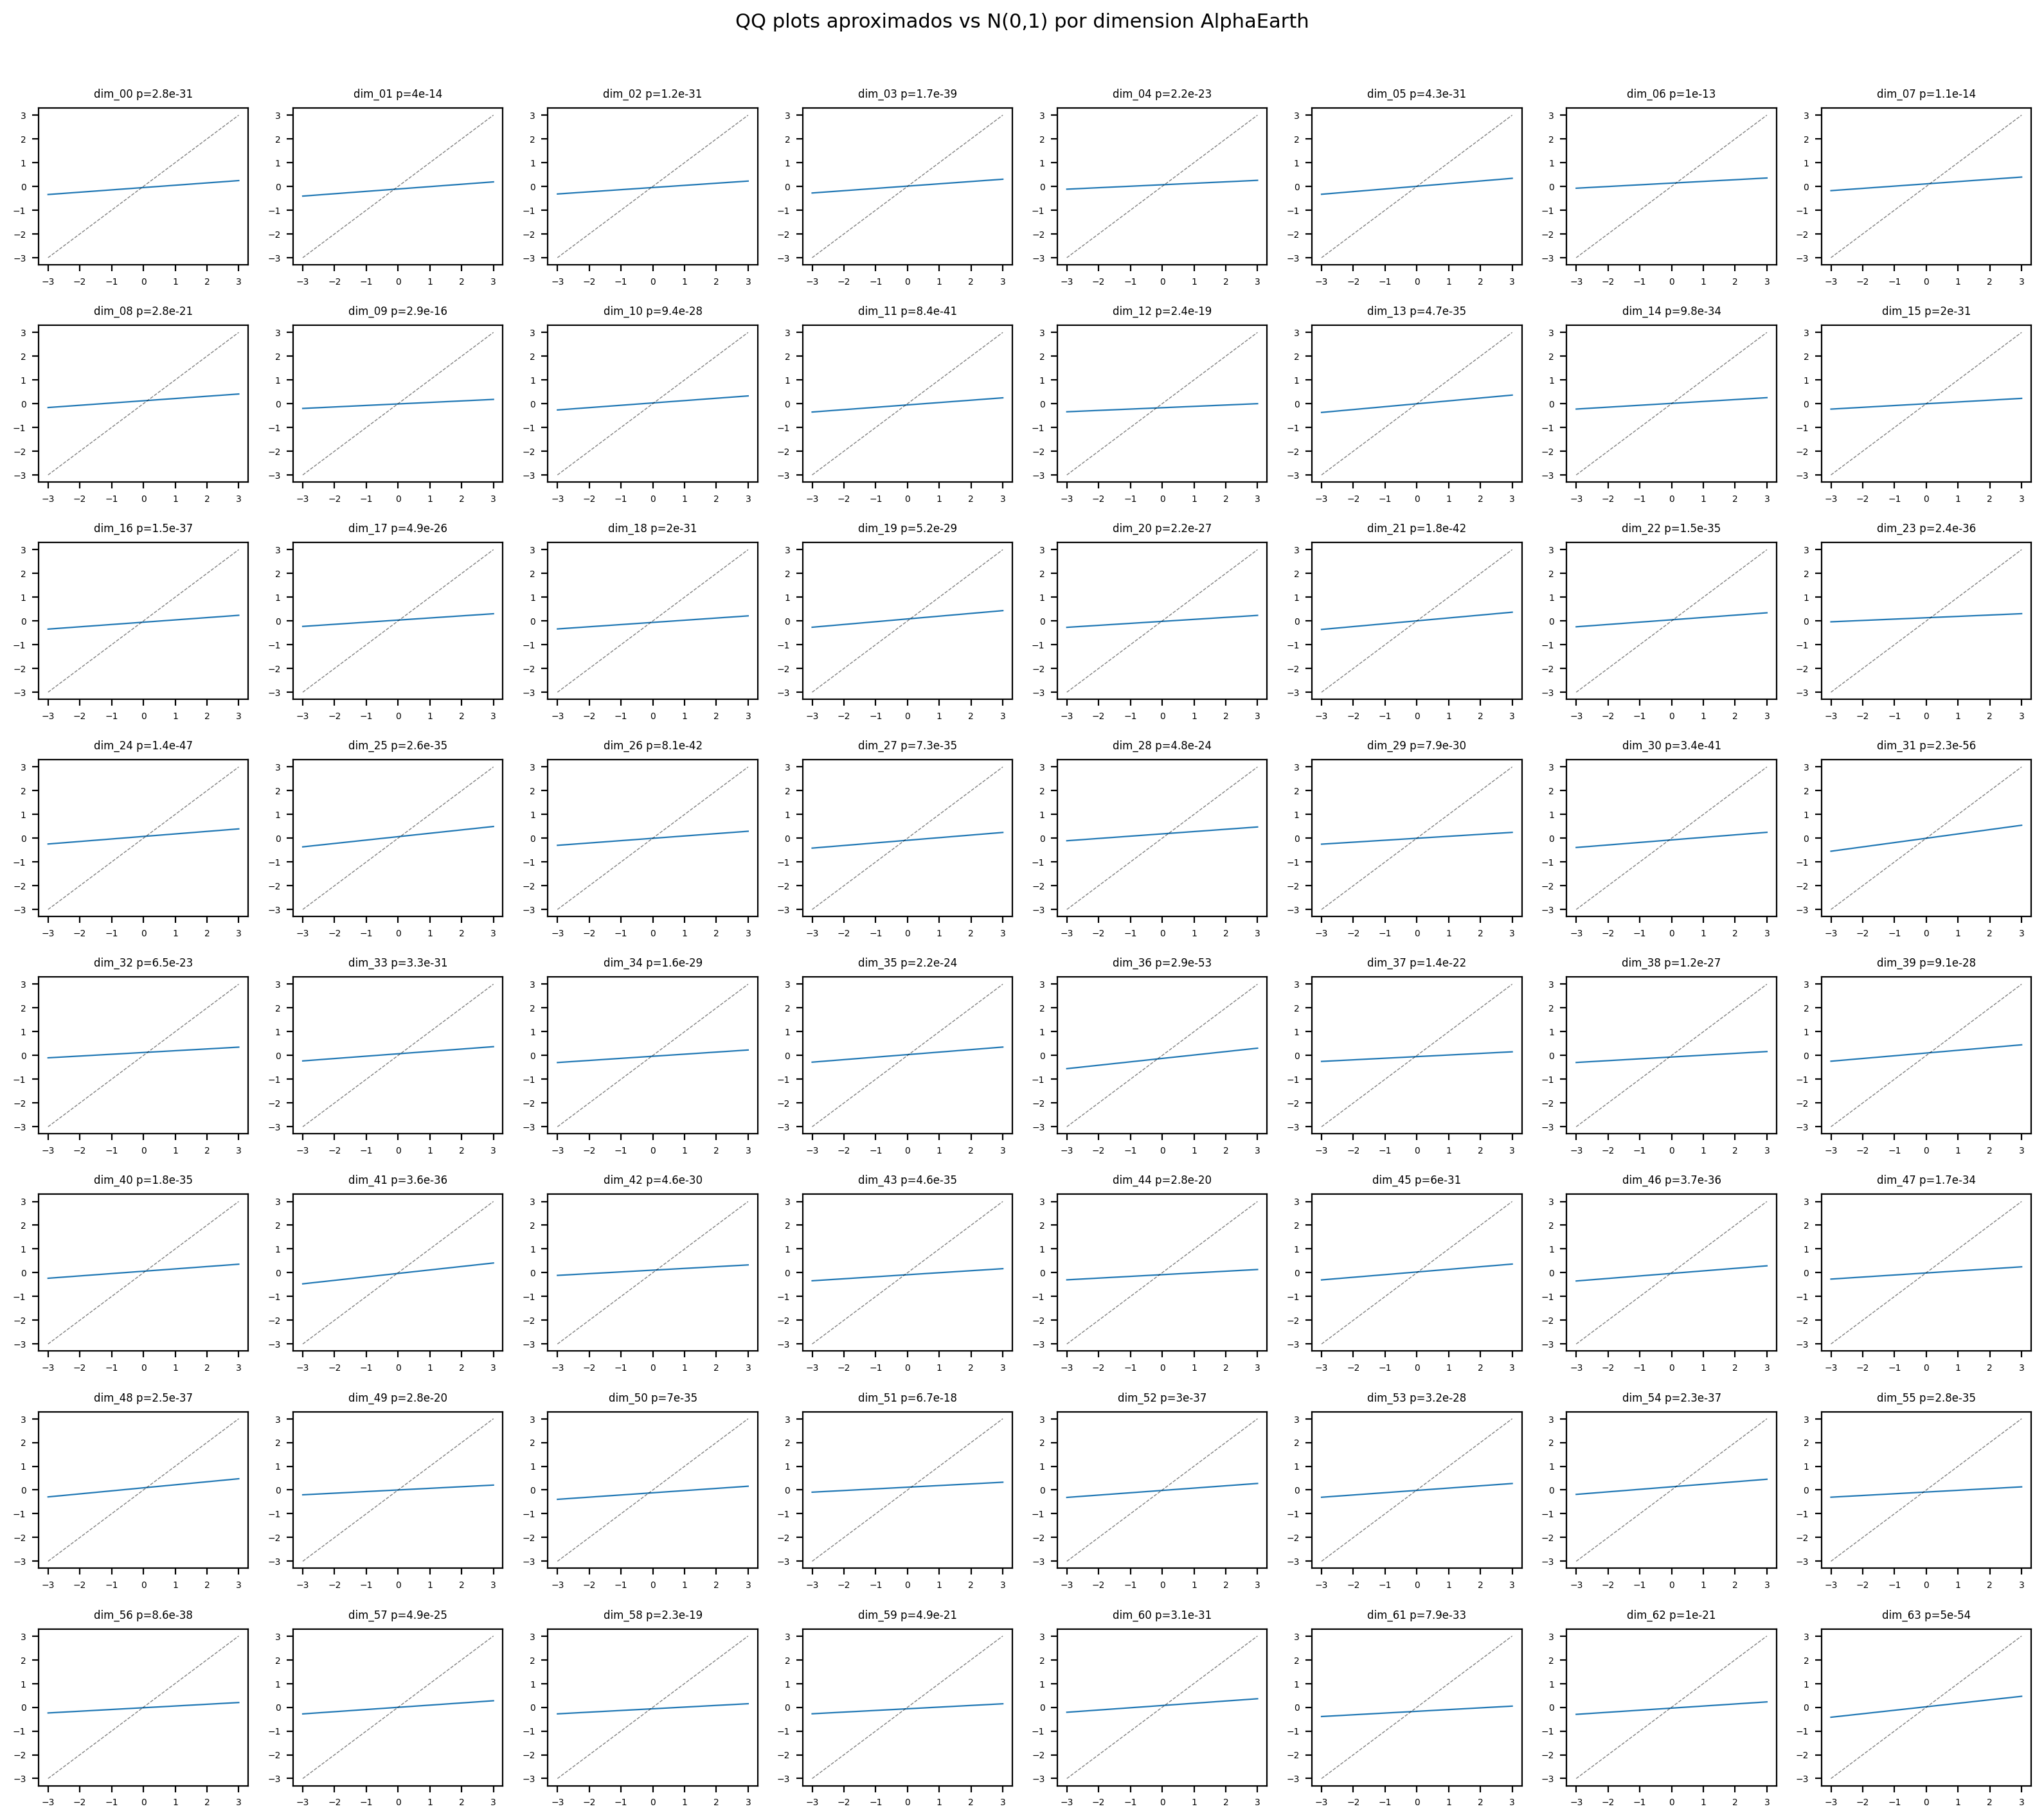

In [6]:
# Distribuciones normales por dimension via tests Q-Q
if not df_italia.is_empty():
    qq_italia = qq_test_dims(df_italia)
    display(Markdown("**Estadísticos QQ por dimensión (primeras 8)**"))
    display(qq_italia.head(8))
    fig_qq = qq_grid(qq_italia, out_path=FIGURES / "sec1_qq_italia_dw.png")
    if fig_qq is not None:
        display(fig_qq)
else:
    qq_italia = pl.DataFrame()

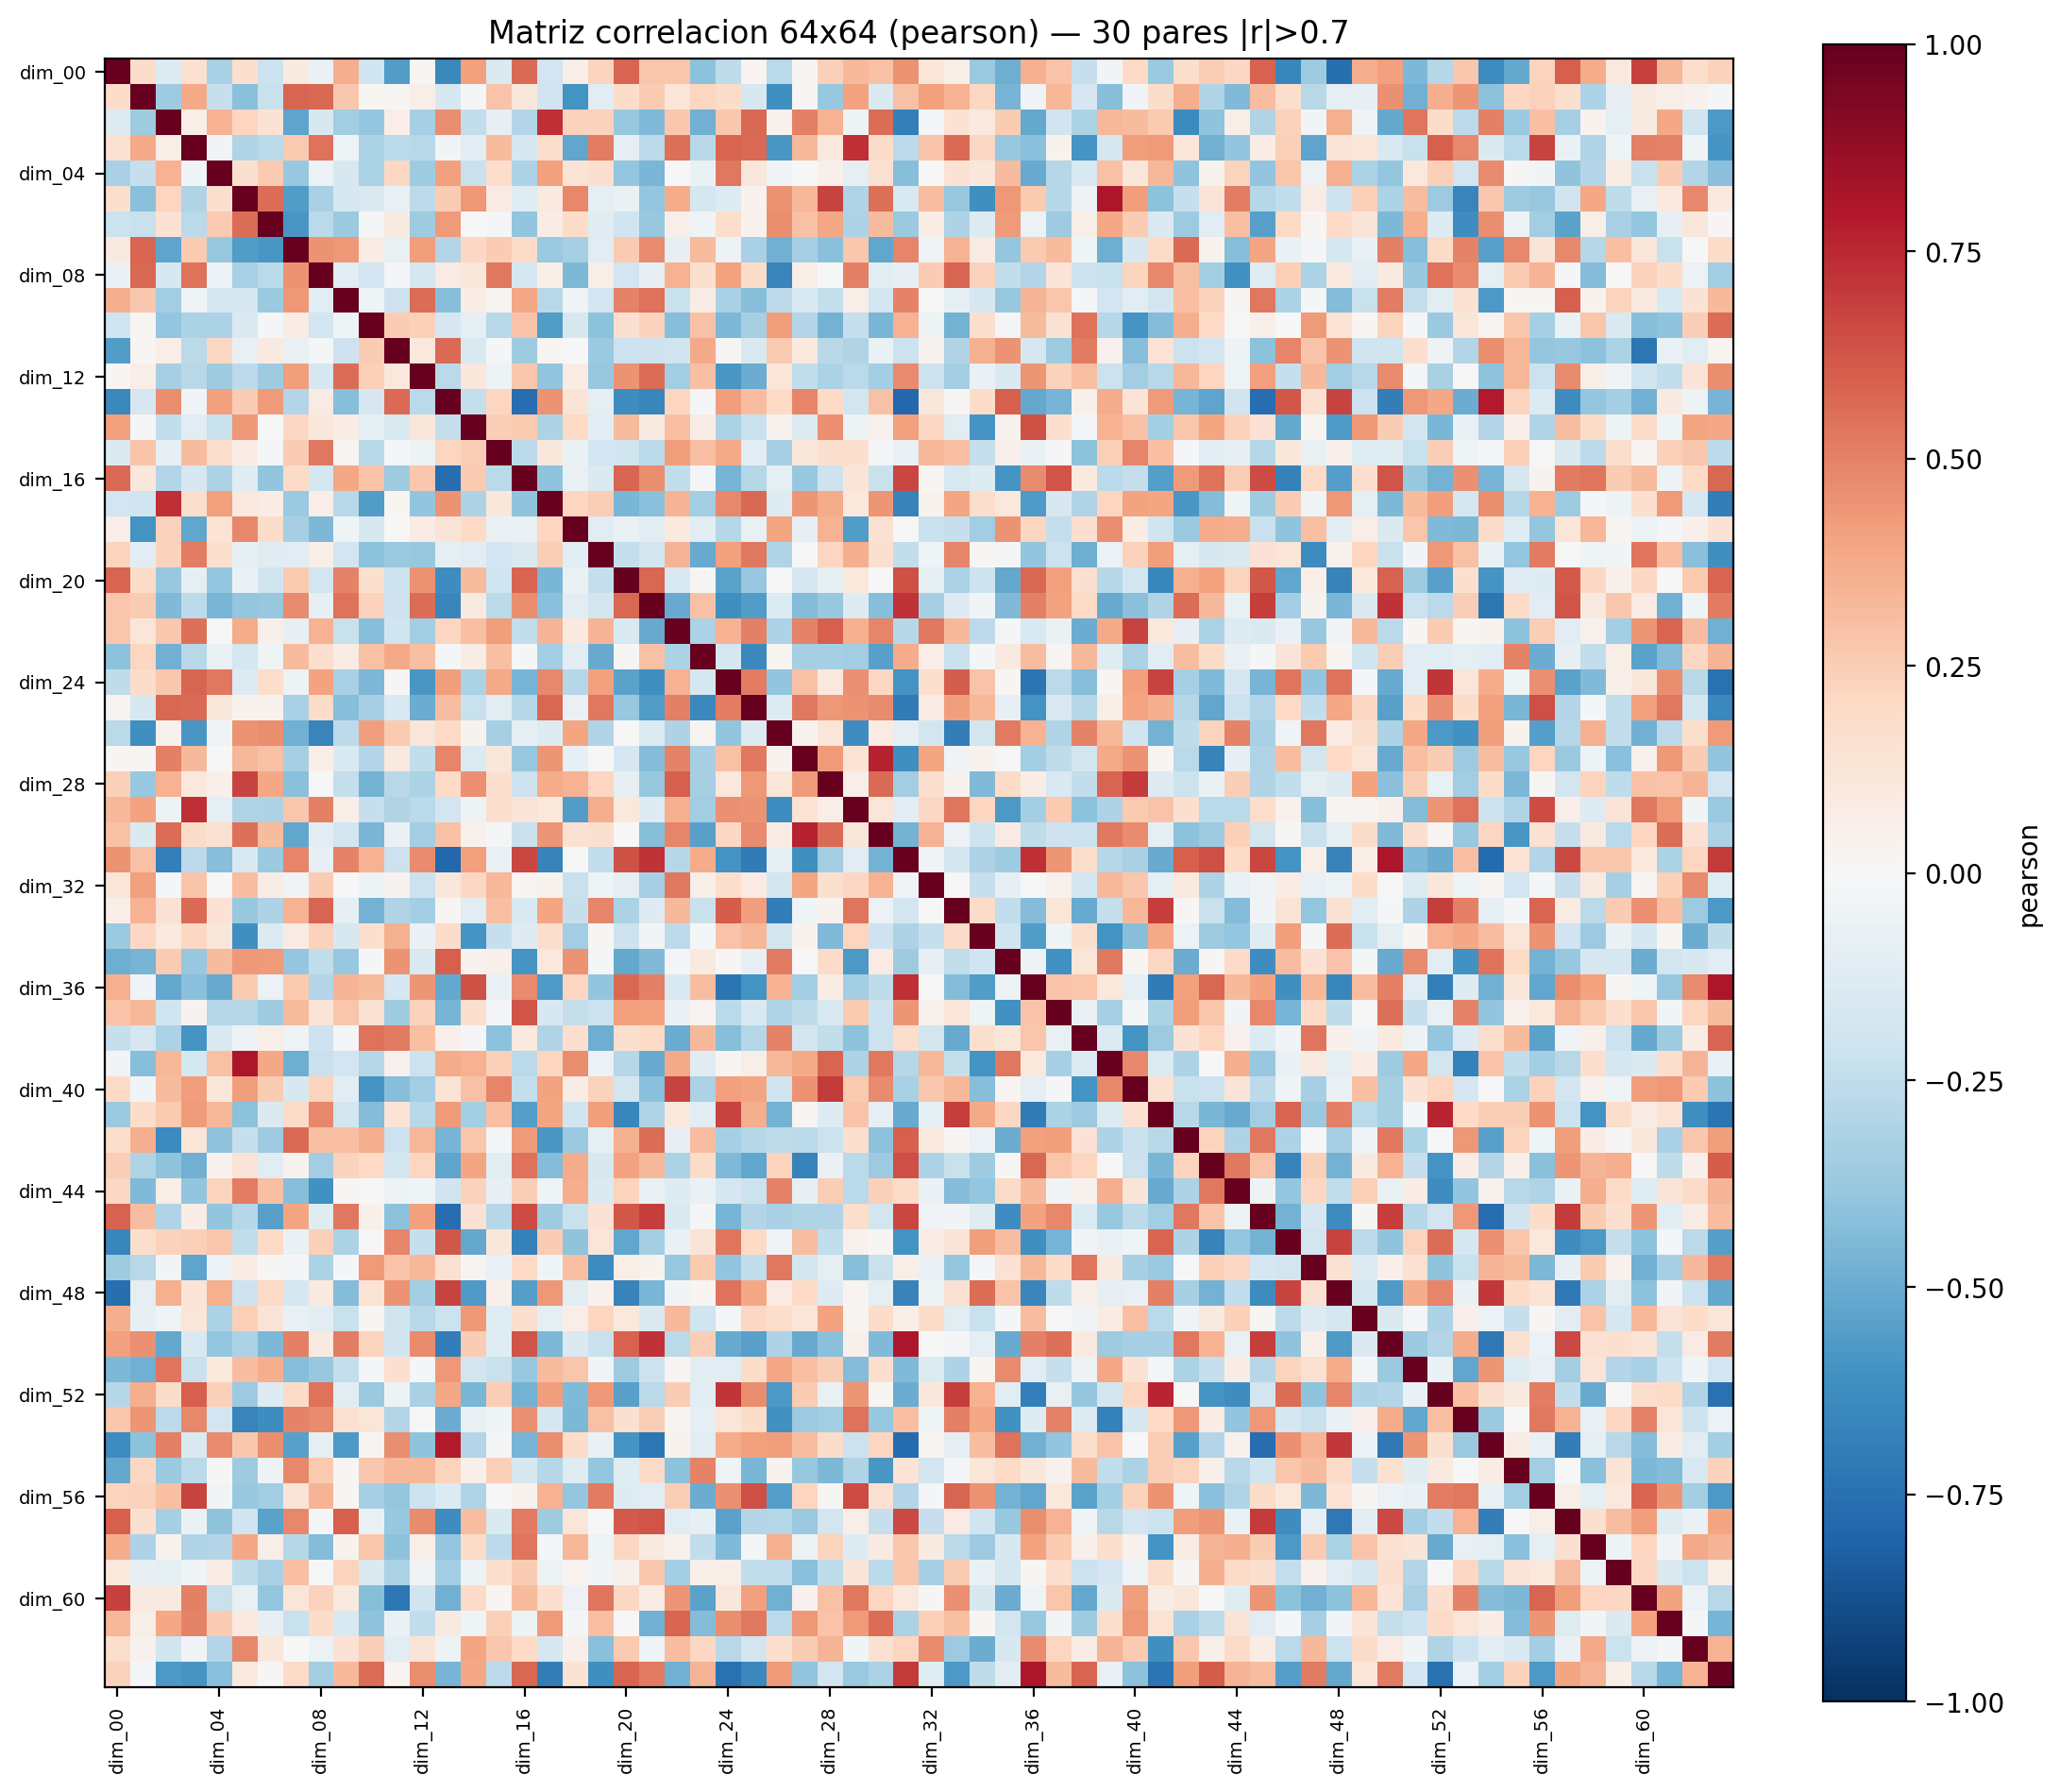

**Pares redundantes en Italia (|r| > 0.7)**

dim_i,dim_j,pearson,abs_corr
str,str,f64,f64
"""dim_05""","""dim_39""",0.811273,0.811273
"""dim_31""","""dim_50""",0.809426,0.809426
"""dim_36""","""dim_63""",0.808563,0.808563
"""dim_13""","""dim_54""",0.793305,0.793305
"""dim_13""","""dim_31""",-0.782837,0.782837
"""dim_27""","""dim_30""",0.768122,0.768122
"""dim_31""","""dim_54""",-0.767442,0.767442
"""dim_45""","""dim_54""",-0.764863,0.764863
"""dim_13""","""dim_45""",-0.761234,0.761234


In [7]:
# Matriz de correlacion 64x64 (detecta dimensiones redundantes)
if not df_italia.is_empty():
    corr_italia = correlation_matrix(df_italia, method="pearson")
    fig_corr = correlation_heatmap(
        corr_italia, out_path=FIGURES / "sec1_corr_italia_dw.png", threshold=0.7
    )
    if fig_corr is not None:
        display(fig_corr)
    display(Markdown("**Pares redundantes en Italia (|r| > 0.7)**"))
    display(
        corr_italia.filter(
            (pl.col("abs_corr") > 0.7) & (pl.col("dim_i") != pl.col("dim_j"))
        ).head(10)
    )
else:
    corr_italia = pl.DataFrame()

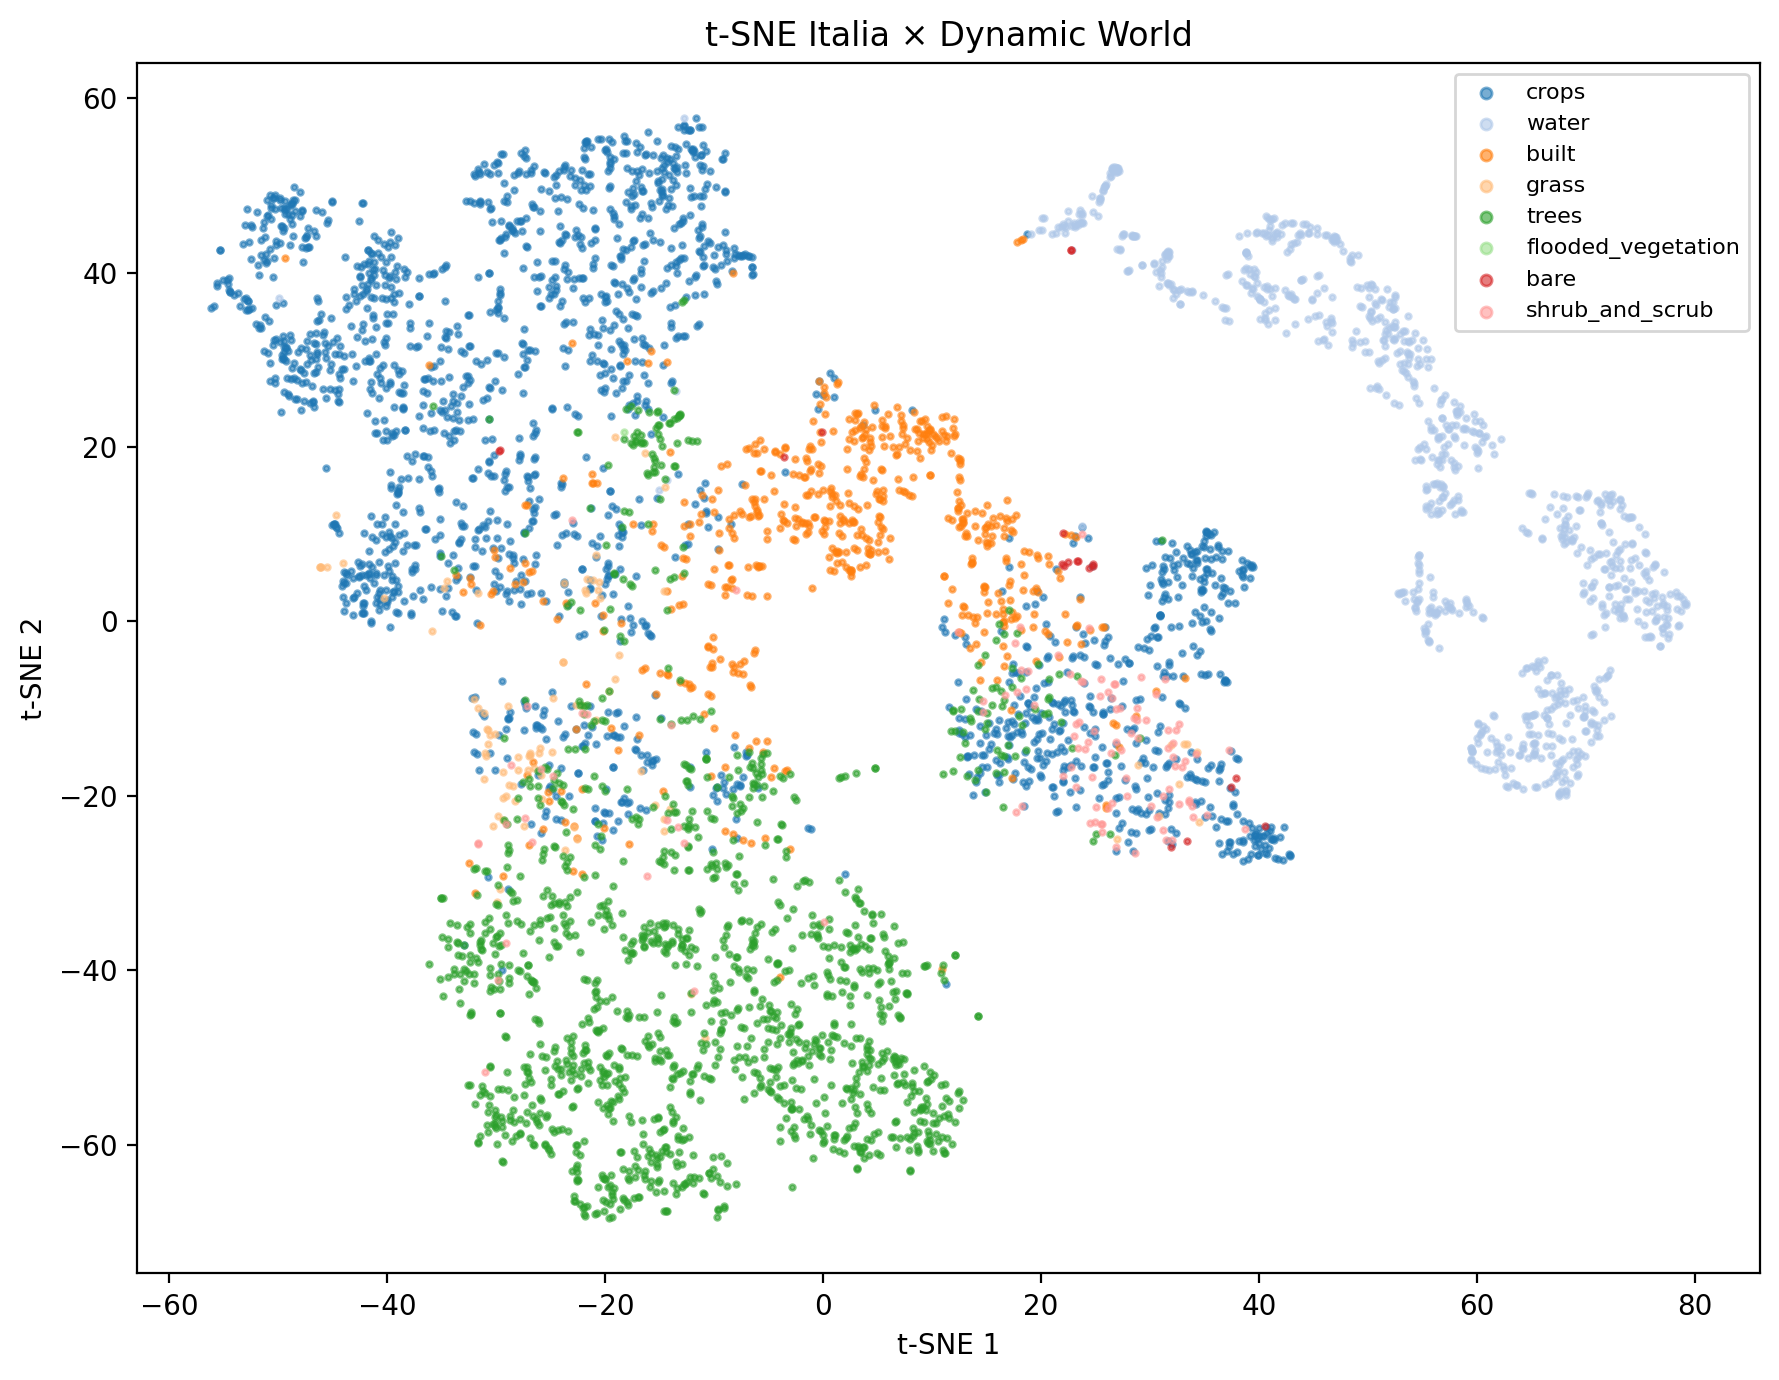

c:\Users\arthu\AppData\Local\pypoetry\Cache\virtualenvs\agrosatcopilot-Kq8fUqSH-py3.12\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


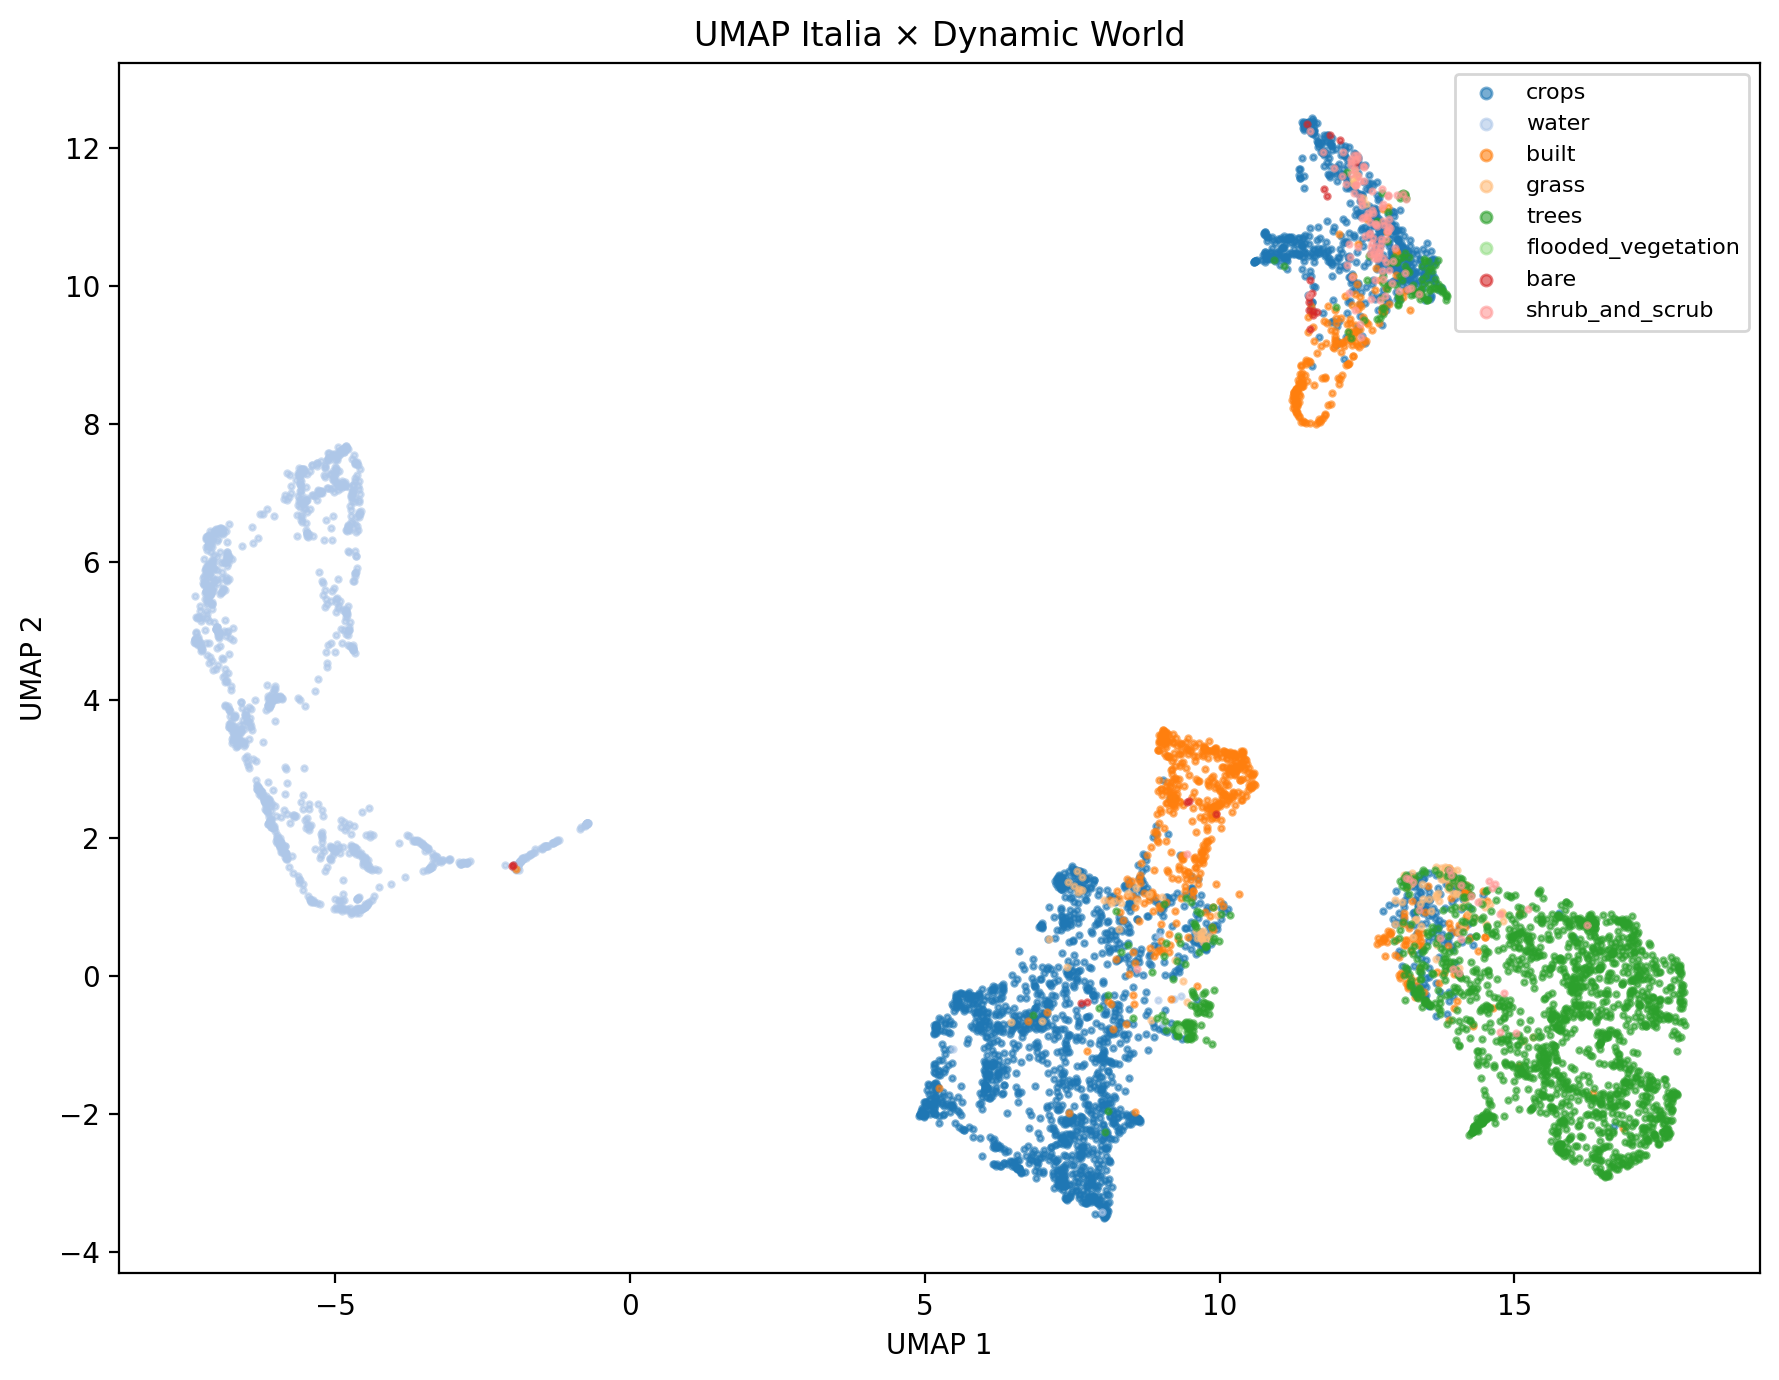

In [8]:
# t-SNE y UMAP de los embeddings, coloreados por clase Dynamic World
if not df_italia.is_empty() and "dw_class_name" in df_italia.columns:
    X_tsne, idx_tsne = tsne_2d(df_italia, subsample=tsne_subsample, seed=42)
    labels_tsne = df_italia["dw_class_name"].to_numpy()[idx_tsne]
    fig_tsne = tsne_scatter(
        X_tsne,
        labels_tsne,
        "t-SNE Italia × Dynamic World",
        FIGURES / "sec1_tsne_italia_dw.png",
    )
    if fig_tsne is not None:
        display(fig_tsne)
    X_umap, idx_umap = umap_2d(df_italia, seed=42)
    if X_umap.shape[0] > 0:
        labels_umap = df_italia["dw_class_name"].to_numpy()[idx_umap]
        fig_umap = umap_scatter(
            X_umap,
            labels_umap,
            "UMAP Italia × Dynamic World",
            FIGURES / "sec1_umap_italia_dw.png",
        )
        if fig_umap is not None:
            display(fig_umap)
else:
    display(Markdown("> Se omite t-SNE/UMAP Italia — sin etiquetas Dynamic World"))

In [9]:
# Random Forest feature importance Italia (que dims ayudan a clasificar mas)
if not df_italia.is_empty() and "dw_class_name" in df_italia.columns:
    df_rf = df_italia.drop_nulls(subset=["dw_class_name", *DIM_COLS])
    rf_italia = rf_feature_importance(
        df_rf.select(DIM_COLS),
        df_rf["dw_class_name"],
        n_estimators=200,
        max_depth=12,
    )
else:
    rf_italia = pl.DataFrame()

if not rf_italia.is_empty():
    display(Markdown("**Top-10 dimensiones AlphaEarth para Italia (importancia Random Forest)**"))
    display(rf_italia.head(10))
    display(Markdown(f"**OOB score Italia**: `{float(rf_italia['oob_score'][0]):.4f}`"))
else:
    display(Markdown("> Se omite Random Forest Italia (DataFrame vacío o sin filas válidas tras dropna)"))

**Top-10 dimensiones AlphaEarth para Italia (importancia Random Forest)**

dim,importance,rank,cumulative_importance,oob_score
str,f64,i64,f64,f64
"""dim_30""",0.045839,1,0.045839,0.8875
"""dim_36""",0.040793,2,0.086632,0.8875
"""dim_16""",0.037643,3,0.124275,0.8875
"""dim_07""",0.035831,4,0.160107,0.8875
"""dim_63""",0.032883,5,0.192989,0.8875
"""dim_13""",0.031201,6,0.22419,0.8875
"""dim_31""",0.030566,7,0.254756,0.8875
"""dim_40""",0.030545,8,0.285302,0.8875
"""dim_06""",0.03031,9,0.315611,0.8875


**OOB score Italia**: `0.8875`

In [10]:
# Estabilidad temporal 2022-2025 (mismas coords, anios distintos)
stability_frames = []
if ee_available and not df_italia.is_empty():
    coords = df_italia.select(["px_id", "lon", "lat"]).unique(subset=["px_id"]).head(500)
    for y in (2022, 2023, 2024, 2025):
        df_y = sample_alphaearth_at_coords(coords, year=y, cache_path=CACHE, cache_key=f"italia_stab_{y}")
        if "class_name" not in df_y.columns:
            df_y = df_y.with_columns(pl.lit("crops").alias("class_name"))
        stability_frames.append(df_y)
if stability_frames:
    df_stab = pl.concat(stability_frames, how="vertical_relaxed")
    stab = temporal_stability(df_stab)
    display(Markdown("**Estabilidad temporal de AlphaEarth 2022–2025 (cosine similarity por clase)**"))
    display(stab.describe())
    display(stab.head(15))
else:
    display(Markdown("> Se omite el análisis de estabilidad temporal (sin Earth Engine)"))

**Estabilidad temporal de AlphaEarth 2022–2025 (cosine similarity por clase)**

statistic,px_id,cosine_2022_2023,cosine_2023_2024,cosine_2024_2025,class_name,cosine_mean
str,str,f64,f64,f64,str,f64
"""count""","""500""",500.0,500.0,500.0,"""500""",500.0
"""null_count""","""0""",0.0,0.0,0.0,"""0""",0.0
"""mean""",null,0.951751,0.953147,0.953686,null,0.952862
"""std""",null,0.054963,0.05588,0.062677,null,0.050361
"""min""","""apulia_2024_102""",0.546187,0.652696,0.539294,"""crops""",0.705083
"""25%""",null,0.944392,0.942967,0.947085,null,0.938584
"""50%""",null,0.967003,0.974595,0.976289,null,0.970493
"""75%""",null,0.981522,0.987209,0.989757,null,0.984509
"""max""","""toscana_centrale_2024_99""",0.998535,0.998129,0.998676,"""crops""",0.997814


px_id,cosine_2022_2023,cosine_2023_2024,cosine_2024_2025,class_name,cosine_mean
str,f64,f64,f64,str,f64
"""apulia_2024_1378""",0.998296,0.997017,0.997829,"""crops""",0.997714
"""pianura_padana_2024_1440""",0.86353,0.747474,0.821294,"""crops""",0.810766
"""pianura_padana_2024_1878""",0.914015,0.734593,0.863671,"""crops""",0.837426
"""pianura_padana_2024_1104""",0.97169,0.937624,0.929426,"""crops""",0.946246
"""apulia_2024_1431""",0.955207,0.974993,0.941367,"""crops""",0.957189
"""apulia_2024_1811""",0.99427,0.992039,0.996051,"""crops""",0.99412
"""toscana_centrale_2024_1827""",0.953123,0.961057,0.966889,"""crops""",0.960356
"""pianura_padana_2024_384""",0.926011,0.93529,0.900075,"""crops""",0.920459
"""pianura_padana_2024_393""",0.967351,0.782589,0.668336,"""crops""",0.806092


Descargando RGB + NDVI Sentinel-2 en la parcela @ (10.4911, 45.2470) ± 0.005°
  RGB shape=(113, 81, 3) rango=[0.000, 1.000] std_por_banda=[0.281, 0.254, 0.254]
  NDVI shape=(113, 81) rango=[0.059, 0.793] media=0.430


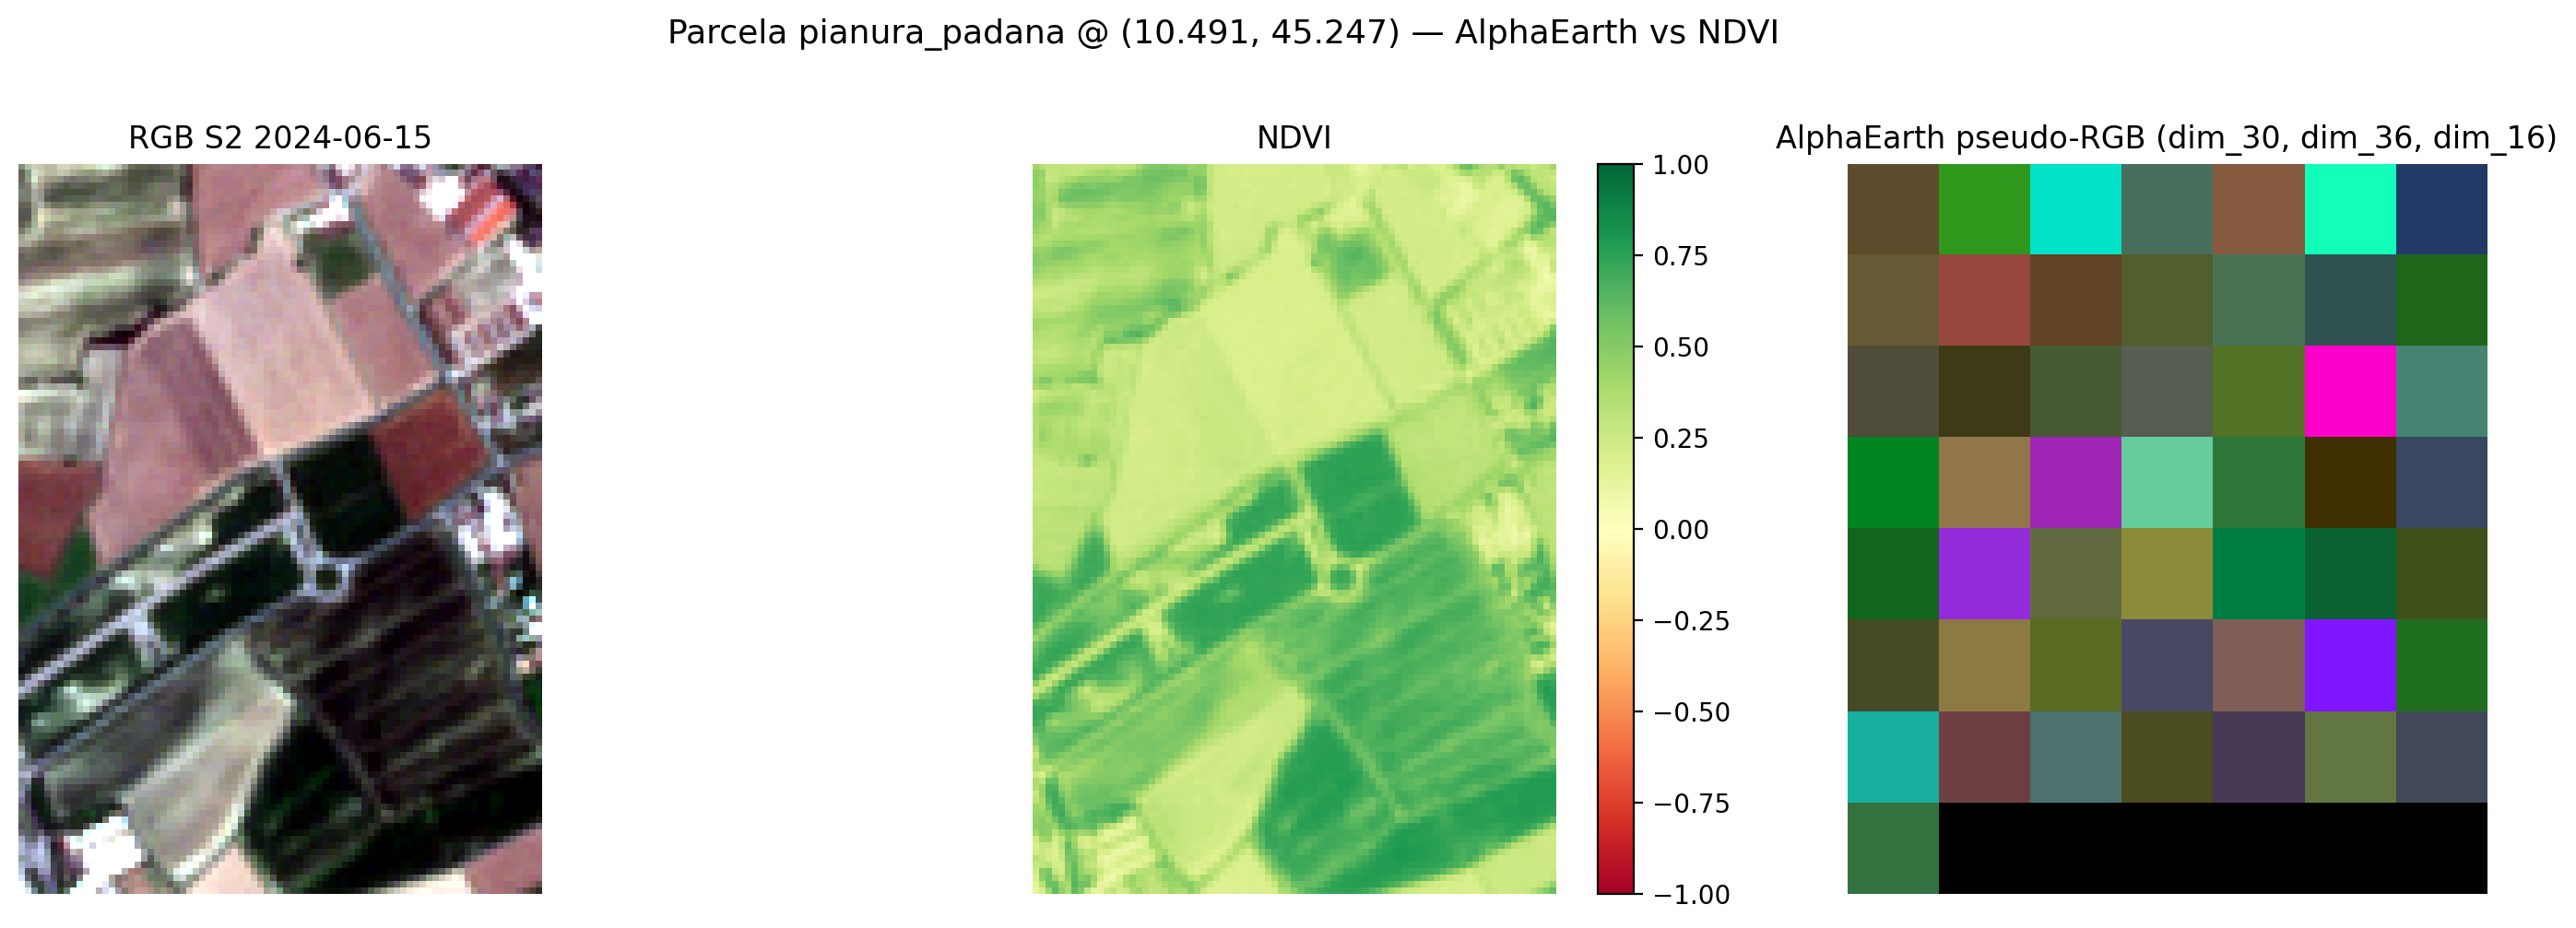

In [11]:
# Comparativa visual AlphaEarth vs NDVI clasico
# Tomamos una sub-parcela contigua: 50 pixeles dentro de un bbox de ~500m
# alrededor del centroide, y fetcheamos RGB+NDVI Sentinel-2 reales en esa
# ventana espacial. Sin esto el plot solo renderiza el pseudo-RGB AlphaEarth.
from ml.ingest.gee_sampler import fetch_s2_ndvi_rgb_for_parcel

rgb_arr = None
ndvi_arr = None

if ee_available and not df_italia.is_empty() and not rf_italia.is_empty():
    top3 = rf_italia.head(3)["dim"].to_list()

    # Elegimos un cluster espacial: 50 pixeles mas cercanos al centroide de
    # Pianura Padana (ROI con mas cobertura agricola en Italia).
    df_pp_only = df_italia.filter(pl.col("roi") == "pianura_padana")
    if df_pp_only.is_empty():
        df_pp_only = df_italia  # fallback si filtro vacio
    lon_c = float(df_pp_only["lon"].median())
    lat_c = float(df_pp_only["lat"].median())

    # Bbox ~500 m alrededor del centroide (~0.005 grados) -> parcela compacta
    delta = 0.005
    parcel_bbox = ee.Geometry.Rectangle(
        [lon_c - delta, lat_c - delta, lon_c + delta, lat_c + delta]
    )
    print(f"Descargando RGB + NDVI Sentinel-2 en la parcela @ ({lon_c:.4f}, {lat_c:.4f}) ± {delta}°")
    s2_payload = fetch_s2_ndvi_rgb_for_parcel(
        parcel_geom=parcel_bbox,
        date=f"{year}-06-15",
        cloud_pct_max=20,
        scale=10,
    )
    rgb_arr = s2_payload["rgb"] if s2_payload["rgb"].size > 0 else None
    ndvi_arr = s2_payload["ndvi"] if s2_payload["ndvi"].size > 0 else None
    if rgb_arr is not None:
        print(
            f"  RGB shape={rgb_arr.shape} rango=[{rgb_arr.min():.3f}, {rgb_arr.max():.3f}] "
            f"std_por_banda={[round(float(rgb_arr[..., c].std()), 3) for c in range(3)]}"
        )
    if ndvi_arr is not None:
        print(
            f"  NDVI shape={ndvi_arr.shape} rango=[{ndvi_arr.min():.3f}, {ndvi_arr.max():.3f}] "
            f"media={ndvi_arr.mean():.3f}"
        )

    sample_parcel = df_pp_only.head(50)
    fig_ndvi = compare_alphaearth_vs_ndvi(
        parcel_id=f"pianura_padana @ ({lon_c:.3f}, {lat_c:.3f})",
        df_embeddings=sample_parcel,
        top_dims=top3,
        s2_date=f"{year}-06-15",
        rgb_array=rgb_arr,
        ndvi_array=ndvi_arr,
        out_path=FIGURES / "sec1_alphaearth_vs_ndvi.png",
    )
    if fig_ndvi is not None:
        display(fig_ndvi)
        plt.close(fig_ndvi)  # evita doble render por auto-show de matplotlib inline
else:
    display(Markdown("> Se omite AlphaEarth vs NDVI — rf_italia o df_italia vacíos"))

## Sección 2 — Francia × PASTIS-R

Sampleamos AlphaEarth en las coordenadas reproyectadas (EPSG:2154 → 4326)
de los patches PASTIS-R. Usamos año 2019 porque es el período de cobertura
real del dataset. Filtramos las clases 0 (background) y 19 (void) antes del
muestreo estratificado.

In [12]:
pastis_meta = REPO / "data" / "PASTIS-R" / "metadata.geojson"
patch_coords = pastis_patch_coords(pastis_meta)
display(Markdown(f"**Patches PASTIS reproyectados (EPSG:2154 → 4326)**: `{patch_coords.height:,}`"))
if patch_coords.is_empty():
    display(Markdown("> PASTIS-R no disponible — la Sección 2 corre en modo placeholder"))
else:
    display(patch_coords.head(8))

**Patches PASTIS reproyectados (EPSG:2154 → 4326)**: `1,087`

patch_id,lon,lat,tile,fold
str,f64,f64,str,i64
"""10000""",-1.261678,49.629423,"""t30uxv""",1
"""10001""",-1.530744,48.930774,"""t30uxv""",2
"""10002""",-1.297111,49.62995,"""t30uxv""",4
"""10003""",-0.357606,49.301395,"""t30uxv""",5
"""10004""",-1.593171,49.196392,"""t30uxv""",4
"""10005""",-1.580542,49.023517,"""t30uxv""",3
"""10006""",-1.557374,49.218979,"""t30uxv""",3
"""10007""",-1.226663,49.617378,"""t30uxv""",1


In [13]:
label_frames = []
if not patch_coords.is_empty():
    pastis_root = REPO / "data" / "PASTIS-R"
    for pid in patch_coords.head(n_pastis_patches)["patch_id"].to_list():
        pdf = pastis_pixel_labels(
            pid,
            root=pastis_root,
            sample_per_patch=max(1, sample_size // n_pastis_patches),
            exclude_classes=(0, 19),
        )
        if not pdf.is_empty():
            label_frames.append(pdf)
df_pastis_labels = pl.concat(label_frames, how="vertical_relaxed") if label_frames else pl.DataFrame()
display(Markdown(f"**Píxeles PASTIS muestreados con etiqueta**: `{df_pastis_labels.height:,}`"))
if not df_pastis_labels.is_empty():
    display(Markdown("**Distribución de cultivos PASTIS-R**"))
    display(
        df_pastis_labels.group_by("class_name")
        .agg(pl.len().alias("n"))
        .sort("n", descending=True)
    )

**Píxeles PASTIS muestreados con etiqueta**: `6,000`

**Distribución de cultivos PASTIS-R**

class_name,n
str,u32
"""Fruits, vegetables, flowers""",2499
"""Meadow""",854
"""Soft winter wheat""",748
"""Corn""",550
"""Spring barley""",269
"""Potatoes""",266
"""Beet""",262
"""Mixed cereal""",246
"""Winter barley""",148


In [14]:
# Sample AlphaEarth en las coords PASTIS reproyectadas
if not df_pastis_labels.is_empty():
    coords_fr = df_pastis_labels.select(["px_id", "lon", "lat"]).unique(subset=["px_id"])
    df_alphaearth_fr = sample_alphaearth_at_coords(
        coords_fr, year=pastis_year, cache_path=CACHE, cache_key="pastis_fr"
    )
    if not df_alphaearth_fr.is_empty():
        df_francia = df_alphaearth_fr.join(
            df_pastis_labels.select(["px_id", "class_id", "class_name"]),
            on="px_id",
            how="inner",
        )
    else:
        df_francia = pl.DataFrame()
else:
    df_francia = pl.DataFrame()
display(Markdown(f"**Francia (AlphaEarth × PASTIS unidos)**: `{df_francia.height:,}` filas"))
if not df_francia.is_empty():
    display(df_francia.head(8))

**Francia (AlphaEarth × PASTIS unidos)**: `6,000` filas

px_id,lon,lat,year,dim_00,dim_01,…,dim_60,dim_61,dim_62,dim_63,class_id,class_name
str,f64,f64,i64,f64,f64,…,f64,f64,f64,f64,i16,str
"""10000_9920""",-1.261606,49.62804,2019,-0.135886,-0.032541,…,0.103406,-0.221453,-0.113741,0.003937,12,"""Fruits, vegetables, flowers"""
"""10000_9649""",-1.263729,49.628244,2019,-0.098424,-0.103406,…,0.108512,-0.16,-0.108512,0.008858,12,"""Fruits, vegetables, flowers"""
"""10000_12455""",-1.265145,49.62599,2019,-0.166336,-0.075356,…,0.059116,-0.179377,-0.022207,-0.044844,12,"""Fruits, vegetables, flowers"""
"""10000_8903""",-1.260615,49.628859,2019,-0.093564,-0.084214,…,0.103406,-0.153787,-0.062991,0.024606,12,"""Fruits, vegetables, flowers"""
"""10000_12805""",-1.269958,49.625683,2019,-0.19291,-0.199862,…,0.044844,-0.079723,-0.022207,-0.084214,1,"""Meadow"""
"""10000_5491""",-1.254386,49.631626,2019,-0.093564,-0.098424,…,0.079723,-0.113741,-0.059116,-0.044844,12,"""Fruits, vegetables, flowers"""
"""10000_15157""",-1.263163,49.623839,2019,-0.214133,-0.119093,…,0.079723,-0.147697,-0.019931,-0.14173,1,"""Meadow"""
"""10000_4010""",-1.26472,49.632753,2019,-0.199862,-0.06699,…,0.044844,-0.186082,-0.048228,-0.027128,12,"""Fruits, vegetables, flowers"""


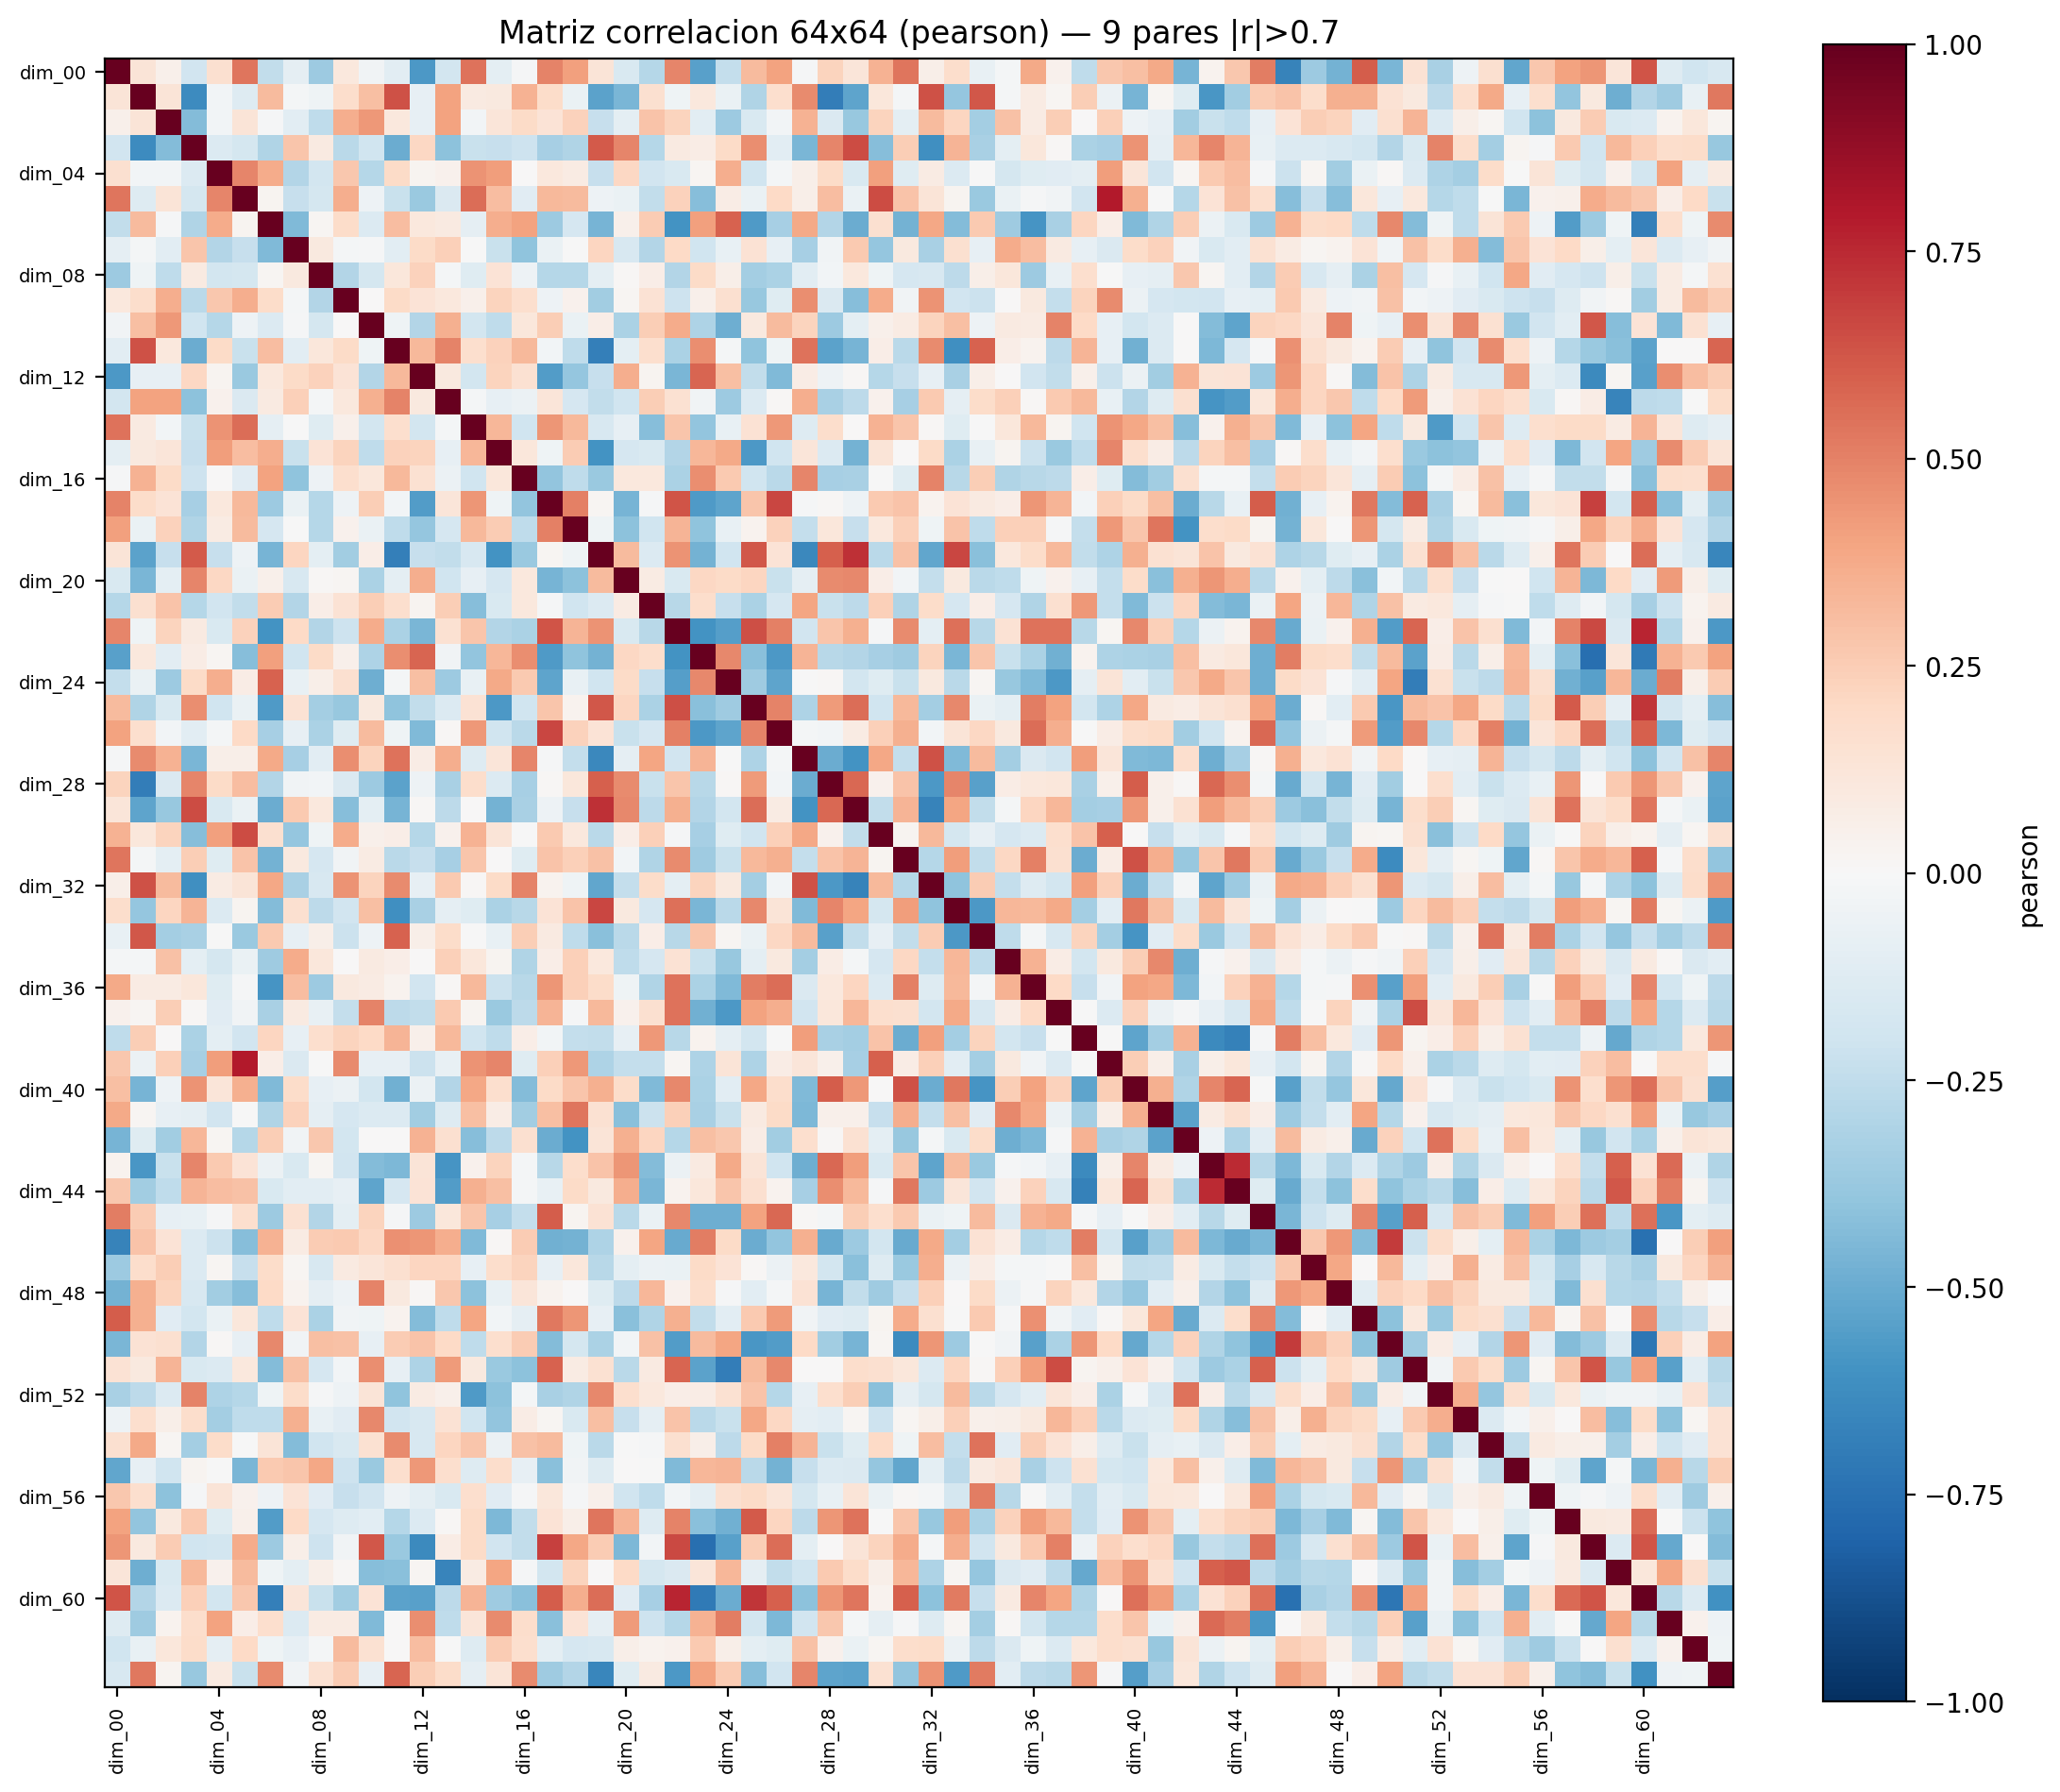

**Pares redundantes en Francia (|r| > 0.7)**

dim_i,dim_j,pearson,abs_corr
str,str,f64,f64
"""dim_05""","""dim_39""",0.79056,0.79056
"""dim_22""","""dim_60""",0.757886,0.757886
"""dim_23""","""dim_58""",-0.754818,0.754818
"""dim_43""","""dim_44""",0.748212,0.748212
"""dim_46""","""dim_60""",-0.747782,0.747782
"""dim_19""","""dim_29""",0.727817,0.727817
"""dim_50""","""dim_60""",-0.720646,0.720646
"""dim_25""","""dim_60""",0.715283,0.715283
"""dim_23""","""dim_60""",-0.710694,0.710694


In [15]:
# Correlacion 64x64 Francia
if not df_francia.is_empty():
    corr_fr = correlation_matrix(df_francia)
    fig_corr_fr = correlation_heatmap(
        corr_fr, out_path=FIGURES / "sec2_corr_francia_pastis.png", threshold=0.7
    )
    if fig_corr_fr is not None:
        display(fig_corr_fr)
    display(Markdown("**Pares redundantes en Francia (|r| > 0.7)**"))
    display(
        corr_fr.filter(
            (pl.col("abs_corr") > 0.7) & (pl.col("dim_i") != pl.col("dim_j"))
        ).head(10)
    )
else:
    corr_fr = pl.DataFrame()

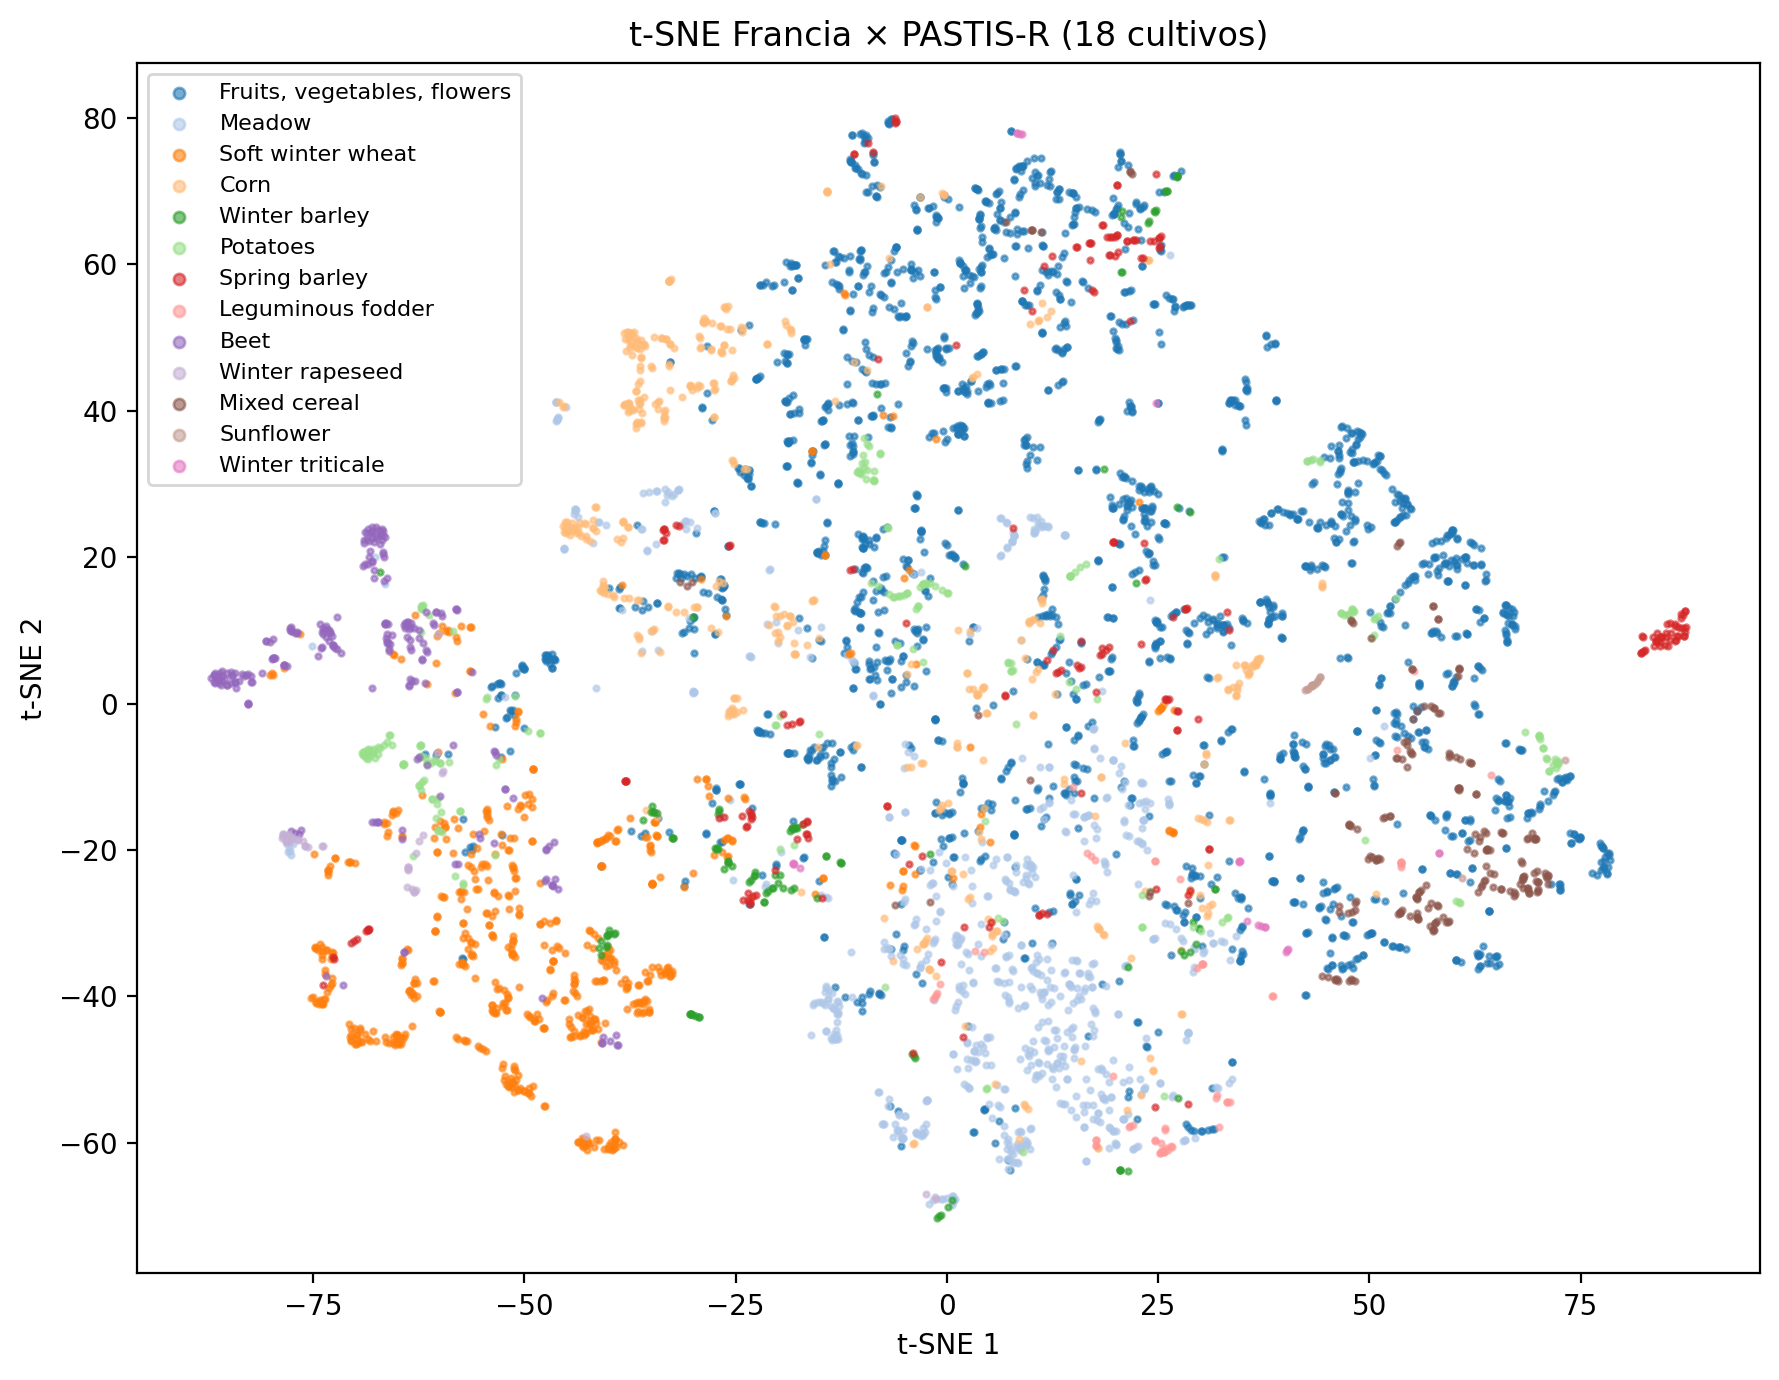

c:\Users\arthu\AppData\Local\pypoetry\Cache\virtualenvs\agrosatcopilot-Kq8fUqSH-py3.12\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


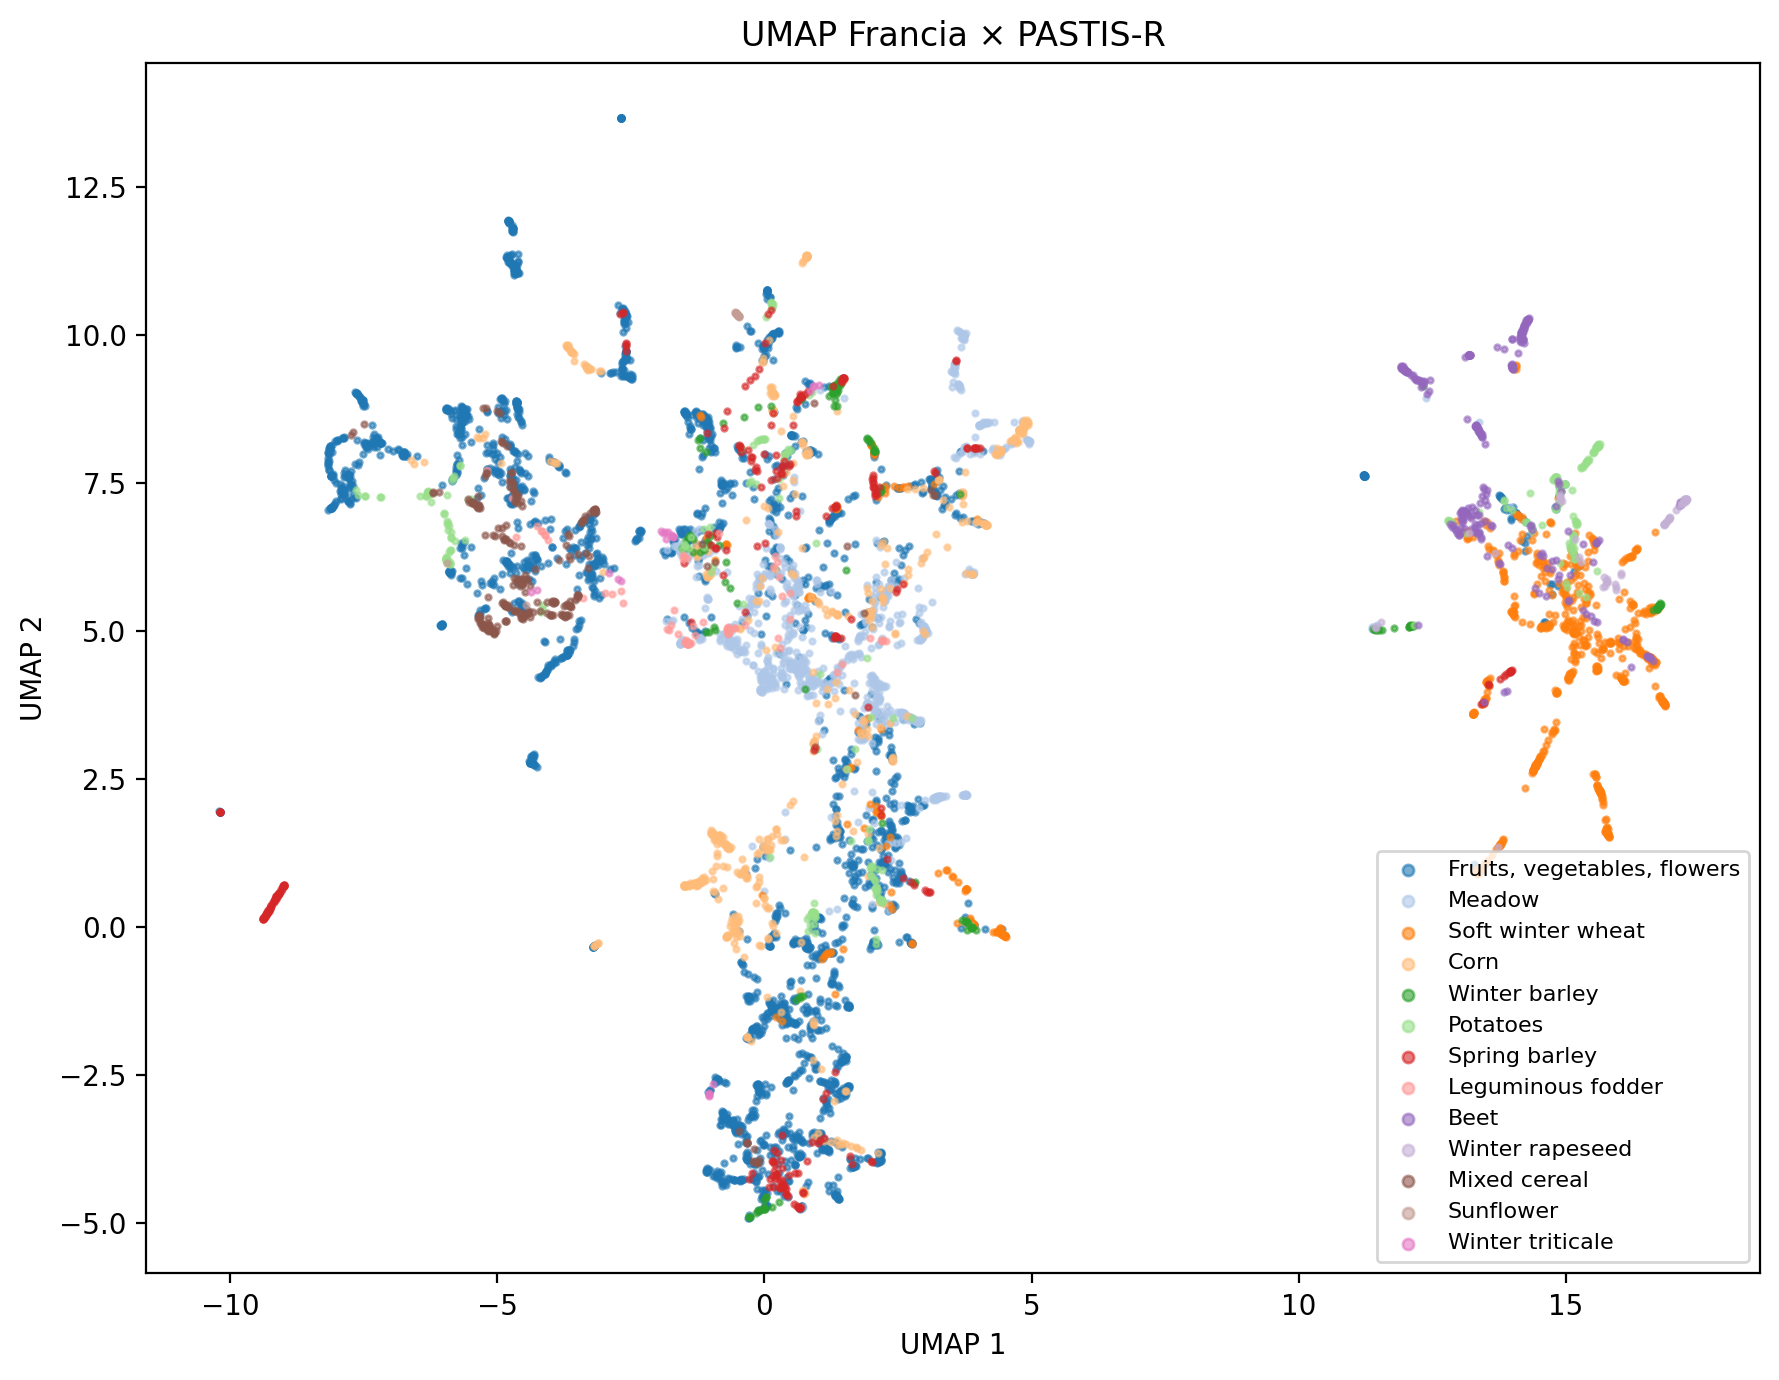

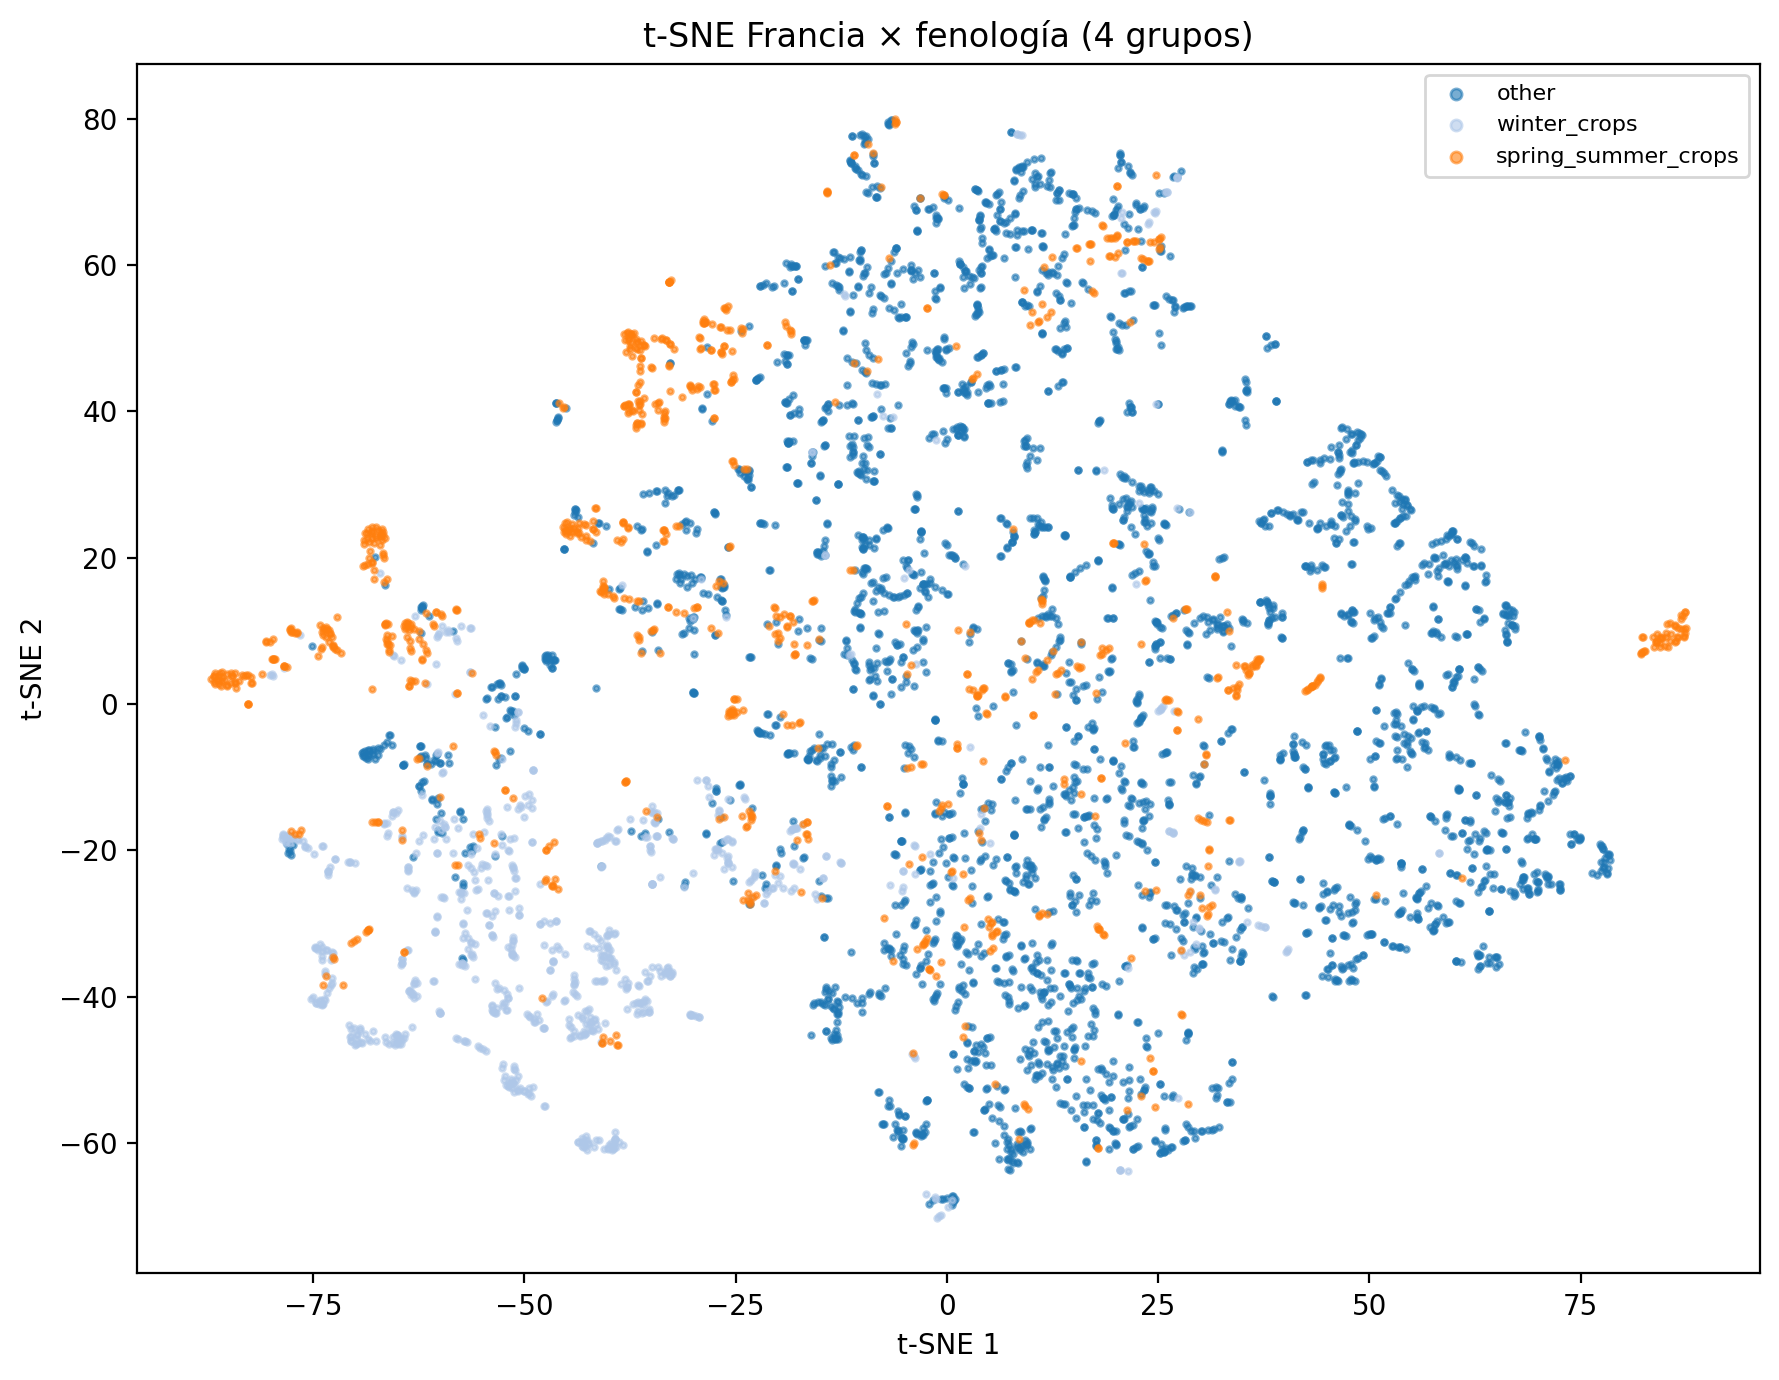

In [16]:
# t-SNE / UMAP Francia coloreados por cultivo
if not df_francia.is_empty() and "class_name" in df_francia.columns:
    X_tsne_fr, idx_fr = tsne_2d(
        df_francia, subsample=min(tsne_subsample, df_francia.height), seed=42
    )
    labels_fr = df_francia["class_name"].to_numpy()[idx_fr]
    fig_tsne_fr = tsne_scatter(
        X_tsne_fr,
        labels_fr,
        "t-SNE Francia × PASTIS-R (18 cultivos)",
        FIGURES / "sec2_tsne_francia_pastis.png",
    )
    if fig_tsne_fr is not None:
        display(fig_tsne_fr)
    X_umap_fr, idx_umap_fr = umap_2d(df_francia, seed=42)
    if X_umap_fr.shape[0] > 0:
        umap_labels_fr = df_francia["class_name"].to_numpy()[idx_umap_fr]
        fig_umap_fr = umap_scatter(
            X_umap_fr,
            umap_labels_fr,
            "UMAP Francia × PASTIS-R",
            FIGURES / "sec2_umap_francia_pastis.png",
        )
        if fig_umap_fr is not None:
            display(fig_umap_fr)
    # Vista agrupada por fenologia (4 clases) - reusa idx_fr de t-SNE
    phen = PASTIS_R_GROUPINGS.get("phenological_cycle", {})
    if phen:
        mapping = pl.DataFrame(
            {"class_id": list(phen.keys()), "phen_group": list(phen.values())},
            schema={"class_id": pl.Int64, "phen_group": pl.Utf8},
        )
        df_phen = df_francia.with_columns(pl.col("class_id").cast(pl.Int64)).join(
            mapping, on="class_id", how="left"
        )
        labels_phen = df_phen["phen_group"].to_numpy()[idx_fr]
        fig_phen = tsne_scatter(
            X_tsne_fr,
            labels_phen,
            "t-SNE Francia × fenología (4 grupos)",
            FIGURES / "sec2_tsne_francia_phenology.png",
        )
        if fig_phen is not None:
            display(fig_phen)
else:
    display(Markdown("> Se omite t-SNE/UMAP Francia — sin df_francia"))

In [17]:
# RF feature importance Francia
if not df_francia.is_empty() and "class_name" in df_francia.columns:
    df_rf_fr = df_francia.drop_nulls(subset=["class_name", *DIM_COLS])
    rf_francia = rf_feature_importance(
        df_rf_fr.select(DIM_COLS),
        df_rf_fr["class_name"],
        n_estimators=200,
        max_depth=12,
    )
else:
    rf_francia = pl.DataFrame()

if not rf_francia.is_empty():
    display(Markdown("**Top-10 dimensiones AlphaEarth para Francia (importancia Random Forest)**"))
    display(rf_francia.head(10))
    display(Markdown(f"**OOB score Francia**: `{float(rf_francia['oob_score'][0]):.4f}`"))
else:
    display(Markdown("> Se omite Random Forest Francia (DataFrame vacío o sin filas válidas tras dropna)"))

**Top-10 dimensiones AlphaEarth para Francia (importancia Random Forest)**

dim,importance,rank,cumulative_importance,oob_score
str,f64,i64,f64,f64
"""dim_10""",0.043523,1,0.043523,0.831
"""dim_55""",0.031824,2,0.075347,0.831
"""dim_05""",0.03118,3,0.106527,0.831
"""dim_32""",0.029949,4,0.136476,0.831
"""dim_40""",0.02949,5,0.165966,0.831
"""dim_60""",0.027242,6,0.193208,0.831
"""dim_24""",0.026678,7,0.219886,0.831
"""dim_58""",0.026628,8,0.246514,0.831
"""dim_28""",0.026317,9,0.272832,0.831


**OOB score Francia**: `0.8310`

## Sección 3 — Comparativa cross-region

Tabla de consistencia entre las top-10 dimensiones AlphaEarth importantes
para clasificar Italia vs Francia. Si una de las dos ejecuciones está vacía
(EE no disponible o PASTIS no descargado), el plot se omite.

**Tabla de consistencia cross-region Italia ↔ Francia**

dim,rank_italia,importance_italia,rank_francia,importance_francia,consistente_top10,delta_rank,importance_sum
str,i64,f64,i64,f64,bool,i64,f64
"""dim_30""",1,0.045839,23,0.016589,false,22,0.062428
"""dim_40""",8,0.030545,5,0.02949,true,3,0.060035
"""dim_36""",2,0.040793,13,0.018868,false,11,0.059661
"""dim_32""",11,0.02502,4,0.029949,false,7,0.054969
"""dim_05""",15,0.019832,3,0.03118,false,12,0.051012
"""dim_60""",14,0.02342,6,0.027242,false,8,0.050662
"""dim_10""",53,0.00668,1,0.043523,false,52,0.050203
"""dim_07""",4,0.035831,32,0.013298,false,28,0.049129
"""dim_55""",24,0.015754,2,0.031824,false,22,0.047578


⚠ **Dimensiones consistentes en el top-10**: `1/10` (requiere regionalización)

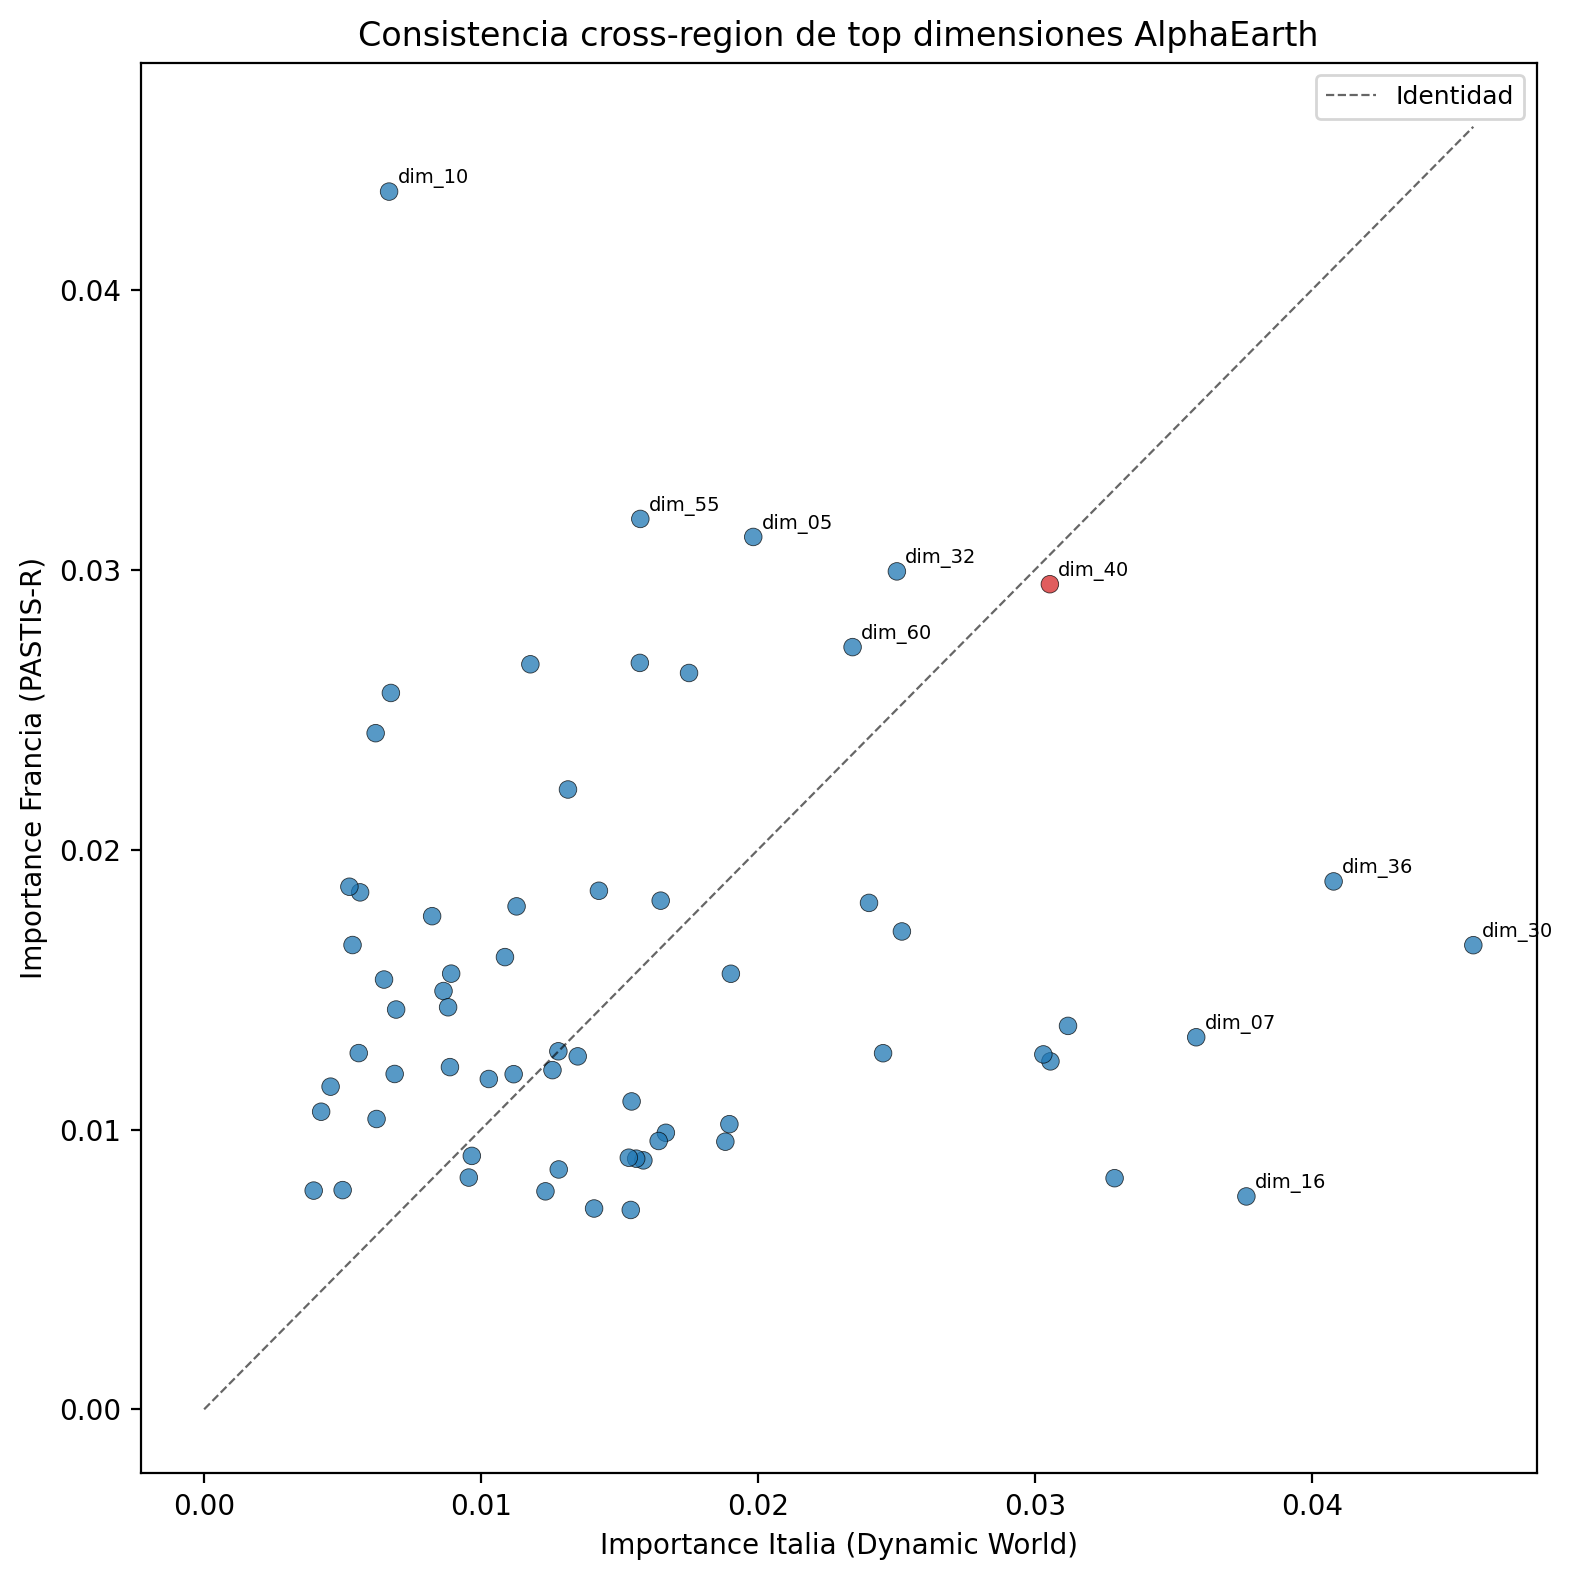

In [18]:
if not rf_italia.is_empty() and not rf_francia.is_empty():
    consistency = cross_region_consistency(rf_italia, rf_francia, top_k=10)
    display(Markdown("**Tabla de consistencia cross-region Italia ↔ Francia**"))
    display(consistency.head(15))
    n_consistent = int(sum(consistency["consistente_top10"].to_list()))
    status = "✓" if n_consistent >= 5 else "⚠"
    veredicto = (
        "baseline global viable" if n_consistent >= 5 else "requiere regionalización"
    )
    display(
        Markdown(
            f"{status} **Dimensiones consistentes en el top-10**: `{n_consistent}/10` ({veredicto})"
        )
    )
    fig_cross = cross_region_scatter(
        consistency, out_path=FIGURES / "sec3_cross_region_consistency.png"
    )
    if fig_cross is not None:
        display(fig_cross)
else:
    consistency = pl.DataFrame()
    display(Markdown("> Se omite la Sección 3 — rf_italia o rf_francia vacíos"))

## Conclusiones — qué aprendimos de los embeddings AlphaEarth

AlphaEarth es un modelo de Google que comprime cada píxel satelital de 10 m
de la Tierra en un vector de 64 números que resume todo lo que pasó ahí
durante un año (reflectancia, textura, fenología, contexto). Aquí evaluamos
si esos 64 números sirven para distinguir tipos de cultivos en dos países muy
diferentes — **Italia** (3 regiones piloto con etiquetas Dynamic World, 6,000
píxeles) y **Francia** (10 patches PASTIS-R con 13 cultivos etiquetados por
agricultores, 5,000 píxeles).

### Lo que funcionó

1. **Los embeddings separan cultivos sin necesidad de feature engineering
   manual.** En los gráficos t-SNE y UMAP se ven clusters claros: campos
   agrícolas se agrupan separados de zonas construidas, agua y bosque. No
   tuvimos que calcular índices (NDVI, EVI, NDWI) — los 64 números ya
   capturaron esa información.

2. **Un clasificador simple sobre los 64 embeddings funciona bien.** Un
   Random Forest básico logra:
   - **OOB score 0.888 en Italia** (8 clases Dynamic World)
   - **OOB score 0.831 en Francia** (13 cultivos PASTIS-R)

   Sin imágenes, sin series temporales, sin DINOv3 — solo el embedding anual.

3. **AlphaEarth carga más señal que el NDVI clásico.** El panel comparativo
   muestra el RGB Sentinel-2 real al lado del "pseudo-RGB" construido con las
   3 dimensiones AlphaEarth más informativas. El pseudo-RGB resalta variación
   estructural (parcelas, caminos) que un solo índice escalar como NDVI
   aplana.

### El hallazgo importante: los embeddings se especializan por región

Cuando comparamos cuáles dimensiones son las más útiles para clasificar en
Italia versus en Francia, **solo 1 de las 10 mejores coincide entre ambas**
(`dim_40`). El resto del top-10 cambia totalmente:

- **Italia** se apoya en `dim_30, dim_36, dim_16, dim_07, dim_63` — dimensiones
  que casi no aparecen en el top de Francia.
- **Francia** se apoya en `dim_10, dim_55, dim_05, dim_32, dim_60` — dimensiones
  que casi no aparecen en el top de Italia.

Esto significa que AlphaEarth aprendió representaciones que **dependen del
contexto regional**: el clima mediterráneo de Apulia, el patrón parcelario
de la Pianura Padana y las rotaciones cereal/colza francesas usan partes
distintas del embedding.

**Consecuencia práctica**: entrenar UN solo clasificador global para Italia
y Francia probablemente rinda menos que entrenar **un clasificador por
región**. Más adelante, cuando construyamos el modelo baseline para predecir
cultivos, vamos a entrenarlos separados.

### Hallazgo: redundancia entre dimensiones

La matriz de correlación 64×64 detecta varios pares de dimensiones con
correlación `|r| > 0.7`. Eso significa que algunas dimensiones cargan
información parecida y podríamos colapsarlas con PCA antes de alimentar
XGBoost. No es bloqueante pero reduce ruido en el modelo final.

### Estabilidad temporal: AlphaEarth es estable entre años

Probamos si los embeddings cambian mucho de un año a otro en las **mismas
coordenadas** (2022, 2023, 2024, 2025). El cosine similarity promedio entre
años consecutivos en 500 píxeles aleatorios fue:

| Comparación | Similaridad promedio | Mediana |
|-------------|----------------------|---------|
| 2022 vs 2023 | 0.952 | 0.967 |
| 2023 vs 2024 | 0.953 | 0.975 |
| 2024 vs 2025 | 0.954 | 0.976 |

Mediana > 0.97 en todos los pares. Esto significa que para parcelas con uso
del suelo constante, **podemos entrenar con un solo año y predecir en años
cercanos sin re-extraer features**. Ahorra cuota GEE y tiempo de cómputo.

### Sobre los grupos fenológicos en Francia

El t-SNE coloreado por ciclo fenológico muestra solo 3 grupos
(`winter_crops`, `spring_summer_crops`, `other`) aunque PASTIS-R define 4.
Los cultivos **permanentes** (viñedos, frutales, olivares) no aparecieron en
el muestreo porque solo procesamos 10 patches PASTIS y son una clase
minoritaria a esa escala. En un muestreo más amplio aparecerían — no es un
bug, es muestreo pequeño.

### Lo que sigue

- **Modelo baseline regional**: entrenar XGBoost por separado para Italia y
  Francia, usando las dims más informativas de cada región.
- **Sanity check NDVI**: comparar XGBoost+AlphaEarth contra XGBoost+NDVI para
  cuantificar la ganancia del Foundation Model sobre un índice clásico.
- **PCA opcional**: colapsar los pares con `|r| > 0.7` antes del clasificador
  para reducir ruido.
- **Comparación con DINOv3**: evaluar si vale la pena pagar el costo
  computacional de un extractor más pesado o si AlphaEarth basta.